In [1]:
import sys
from pathlib import Path

# Save the notebook's OutStream BEFORE importing train.py, which replaces
# sys.stdout/stderr with raw file-descriptor wrappers (for DDP line-buffering).
# Those wrappers call fileno() on the notebook's OutStream, grab fd=1 (the
# terminal), and redirect all prints away from the cell output.
_nb_stdout = sys.stdout
_nb_stderr = sys.stderr

ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython import get_ipython
from IPython.display import display
from scipy.stats import pearsonr, spearmanr
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.manifold import TSNE
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

from train import ExpressionPerformer

# Restore the notebook's output streams now that train.py has overwritten them.
sys.stdout = _nb_stdout
sys.stderr = _nb_stderr

ip = get_ipython()
if ip is not None:
    ip.run_line_magic("matplotlib", "inline")
try:
    plt.switch_backend("module://matplotlib_inline.backend_inline")
except Exception:
    pass
matplotlib.rcParams["figure.dpi"] = 110


def show_figure(fig=None):
    """Robustly display a matplotlib figure in notebook output."""
    if fig is None:
        fig = plt.gcf()
    display(fig)
    plt.close(fig)


sns.set_theme(style="whitegrid")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device = {device}")


device = cuda


In [2]:
RUN_DIR = ROOT / "checkpoints_performer/20jo1hdd"
CHECKPOINT_PATH = RUN_DIR / "best_model.pt"

OSDR_METADATA_PATH = ROOT / "data/osdr/metadata/selected_sample_metadata.tsv"
ORTHOLOGS_PATH = ROOT / "data/ensembl/orthologs_one2one.txt"
CANONICAL_GENES_PATH = ROOT / "data/archs4/train_orthologs/canonical_genes.csv"
MOUSE_EXON_LENGTHS_PATH = ROOT / "data/gencode/gencode_v49_mouse_gene_exon_lengths.csv"
QC_MIN_NONZERO = 14_000

assert CHECKPOINT_PATH.exists(), f"Missing checkpoint: {CHECKPOINT_PATH}"
assert OSDR_METADATA_PATH.exists(), f"Missing OSDR metadata: {OSDR_METADATA_PATH}"
assert ORTHOLOGS_PATH.exists(), f"Missing ortholog file: {ORTHOLOGS_PATH}"
assert CANONICAL_GENES_PATH.exists(), f"Missing canonical gene file: {CANONICAL_GENES_PATH}"
assert MOUSE_EXON_LENGTHS_PATH.exists(), f"Missing mouse exon lengths file: {MOUSE_EXON_LENGTHS_PATH}"


def build_mouse_to_human_maps(orthologs_path, mouse_exon_lengths_path):
    ortho = pd.read_csv(orthologs_path, sep="\t")
    ortho = ortho[ortho["Human homology type"] == "ortholog_one2one"].copy()
    ortho["Gene stable ID"] = ortho["Gene stable ID"].astype(str).str.split(".").str[0]

    ensembl_to_human = dict(zip(ortho["Gene stable ID"], ortho["Human gene name"]))
    ensembl_to_mouse_symbol = dict(zip(ortho["Gene stable ID"], ortho["Gene name"]))

    mouse_lengths = pd.read_csv(mouse_exon_lengths_path).drop_duplicates("gene_symbol")
    mouse_lengths = mouse_lengths.set_index("gene_symbol")["exon_length"]

    human_length_map = {}
    for _, row in ortho[["Human gene name", "Gene name"]].drop_duplicates().iterrows():
        h = row["Human gene name"]
        m = row["Gene name"]
        if m in mouse_lengths.index and mouse_lengths[m] > 0 and h not in human_length_map:
            human_length_map[h] = float(mouse_lengths[m])

    return ensembl_to_human, ensembl_to_mouse_symbol, human_length_map


def normalize_counts_to_tpm(count_df, exon_len_by_human_gene):
    lengths_bp = pd.Series(exon_len_by_human_gene, dtype=np.float64).reindex(count_df.columns)
    keep_mask = lengths_bp.notna() & (lengths_bp > 0)
    counts_use = count_df.loc[:, keep_mask].astype(np.float32)
    lengths_kb = (lengths_bp.loc[keep_mask] / 1000.0).astype(np.float32)

    rate = counts_use.div(lengths_kb, axis=1)
    denom = rate.sum(axis=1).replace(0, np.nan)
    tpm = rate.div(denom, axis=0) * 1e6
    tpm = tpm.reindex(columns=count_df.columns, fill_value=0.0).fillna(0.0)
    return tpm.astype(np.float32)


def load_osdr_inputs():
    meta = pd.read_csv(OSDR_METADATA_PATH, sep="\t")
    n_meta_initial = int(len(meta))

    meta = meta[meta["study.characteristics.organism"].astype(str).str.contains("Mus musculus", case=False, na=False)].copy()
    n_meta_mouse = int(len(meta))

    meta = meta[meta["counts_path"].notna()].copy()
    n_meta_with_counts_path = int(len(meta))

    sf_raw = meta["study.factor value.spaceflight"]
    missing_sf_mask = (
        sf_raw.isna()
        | sf_raw.astype(str).str.strip().eq("")
        | sf_raw.astype(str).str.strip().str.lower().isin(["nan", "none", "na", "n/a"])
    )
    n_missing_spaceflight_field = int(missing_sf_mask.sum())
    meta = meta[~missing_sf_mask].copy()

    meta["sample_name"] = meta["id.sample name"].astype(str)
    meta["sample_id"] = meta["id.accession"].astype(str) + "|" + meta["sample_name"]
    sf = meta["study.factor value.spaceflight"].astype(str)
    meta["label"] = np.where(sf.str.contains("space flight", case=False, na=False), "Space Flight", "Non-Spaceflight")

    canonical_genes = pd.read_csv(CANONICAL_GENES_PATH)["gene_symbol"].astype(str).tolist()
    canonical_gene_set = set(canonical_genes)
    ensembl_to_human, _, human_length_map = build_mouse_to_human_maps(ORTHOLOGS_PATH, MOUSE_EXON_LENGTHS_PATH)

    sample_frames = []
    missing_sample_rows = []
    qc_dropped_samples = []
    n_samples_seen_before_qc = 0
    n_samples_retained_after_qc = 0

    for counts_path, group in meta.groupby("counts_path", sort=False):
        full_path = ROOT / str(counts_path)
        if not full_path.exists():
            missing_sample_rows.extend(group["sample_id"].tolist())
            continue

        counts_df = pd.read_csv(full_path, index_col=0)
        counts_df.index = counts_df.index.astype(str).str.replace(r"\..*$", "", regex=True)
        counts_df.columns = counts_df.columns.astype(str)

        name_to_id = group.drop_duplicates("sample_name").set_index("sample_name")["sample_id"].to_dict()
        present_names = [n for n in name_to_id if n in counts_df.columns]
        missing_names = [n for n in name_to_id if n not in counts_df.columns]
        missing_sample_rows.extend([name_to_id[n] for n in missing_names])

        if not present_names:
            continue

        sub = counts_df[present_names].copy()
        sub.columns = [name_to_id[n] for n in present_names]

        # Match preprocessing.py QC: keep samples with >=14k non-zero genes.
        nonzero_per_sample = (sub > 0).sum(axis=0)
        keep_sample_ids = nonzero_per_sample[nonzero_per_sample >= QC_MIN_NONZERO].index.tolist()
        drop_sample_ids = nonzero_per_sample[nonzero_per_sample < QC_MIN_NONZERO].index.tolist()

        n_samples_seen_before_qc += int(len(nonzero_per_sample))
        n_samples_retained_after_qc += int(len(keep_sample_ids))
        qc_dropped_samples.extend(drop_sample_ids)

        if not keep_sample_ids:
            continue

        sub = sub[keep_sample_ids].copy()
        sample_frames.append(sub.T)

    if not sample_frames:
        raise ValueError("No OSDR samples matched metadata to count-matrix columns after QC filtering.")

    X_mouse = pd.concat(sample_frames, axis=0)
    X_mouse = X_mouse[~X_mouse.index.duplicated(keep="first")].astype(np.float32)

    gene_map = pd.Series(X_mouse.columns, index=X_mouse.columns).map(ensembl_to_human)
    keep_cols = gene_map.notna()
    unmapped_mouse_genes = int((~keep_cols).sum())

    X_human_pre = X_mouse.loc[:, keep_cols.values].copy()
    X_human_pre.columns = gene_map[keep_cols].values
    X_human_pre = X_human_pre.T.groupby(level=0).sum().T

    sample_human_gene_set = set(X_human_pre.columns.astype(str).tolist())
    genes_in_samples_not_in_model_set = sample_human_gene_set - canonical_gene_set
    genes_in_model_not_in_samples_set = canonical_gene_set - sample_human_gene_set

    X_human = X_human_pre.reindex(columns=canonical_genes, fill_value=0.0).astype(np.float32)
    X_tpm = normalize_counts_to_tpm(X_human, human_length_map)

    meta = meta.drop_duplicates("sample_id").set_index("sample_id")
    shared = meta.index.intersection(X_human.index).intersection(X_tpm.index)
    meta = meta.loc[shared].copy()
    X_human = X_human.loc[shared].copy()
    X_tpm = X_tpm.loc[shared].copy()

    observed_gene_counts = (X_human > 0).sum(axis=1).astype(np.int32)

    summary = {
        "num_samples": int(len(shared)),
        "num_genes_model_space": int(X_human.shape[1]),
        "spaceflight_samples": int((meta["label"] == "Space Flight").sum()),
        "non_spaceflight_samples": int((meta["label"] == "Non-Spaceflight").sum()),
        "missing_metadata_mapped_samples": int(len(missing_sample_rows)),
        "ingest_diagnostics": {
            "metadata_rows_initial": n_meta_initial,
            "metadata_rows_mouse": n_meta_mouse,
            "metadata_rows_with_counts_path": n_meta_with_counts_path,
            "metadata_rows_dropped_missing_spaceflight_field": n_missing_spaceflight_field,
            "qc_min_nonzero_genes_threshold": int(QC_MIN_NONZERO),
            "samples_seen_before_qc": int(n_samples_seen_before_qc),
            "samples_retained_after_qc": int(n_samples_retained_after_qc),
            "samples_dropped_low_detected_genes": int(len(qc_dropped_samples)),
            "mouse_genes_observed_total": int(X_mouse.shape[1]),
            "mouse_genes_without_human_one2one_mapping": unmapped_mouse_genes,
            "human_genes_observed_after_mapping": int(len(sample_human_gene_set)),
            "model_gene_list_size": int(len(canonical_genes)),
            "genes_in_samples_not_in_model_list": int(len(genes_in_samples_not_in_model_set)),
            "genes_in_model_list_not_observed_in_samples": int(len(genes_in_model_not_in_samples_set)),
            "observed_genes_per_sample_mean": float(observed_gene_counts.mean()),
            "observed_genes_per_sample_median": float(observed_gene_counts.median()),
            "observed_genes_per_sample_min": int(observed_gene_counts.min()),
            "observed_genes_per_sample_max": int(observed_gene_counts.max()),
            "observed_gene_fraction_per_sample_mean": float(observed_gene_counts.mean() / max(len(canonical_genes), 1)),
        },
    }
    return X_human, X_tpm, meta, canonical_genes, summary


def build_expression_performer(cfg, num_genes, device):
    model = ExpressionPerformer(
        num_genes=num_genes,
        hidden_dim=cfg["hidden_dim"],
        n_heads=cfg["num_heads"],
        n_layers=cfg["num_layers"],
        ffn_dim=cfg["ffn_dim"],
        ree_base=cfg["ree_base"],
        mask_token_id=cfg.get("mask_token", -10),
        feature_type=cfg.get("feature_type", "sqr"),
        compute_type=cfg.get("compute_type", "iter"),
    )
    model = model.to(device)
    model.eval()
    return model


def encode_hidden_states(model, x):
    _, num_genes = x.shape
    gene_ids = torch.arange(num_genes, device=x.device)
    gene_emb = model.gene_embedding(gene_ids)
    ree_emb = model.ree(x)
    hidden = gene_emb.unsqueeze(0) + ree_emb
    for layer in model.layers:
        rfs = layer.attention.sample_rfs(x.device)
        hidden = layer.full_forward(hidden, rfs)
    return hidden


def predict_expression(model, expr_array, batch_size=16, device=device):
    expr_tensor = torch.tensor(expr_array, dtype=torch.float32)
    loader = DataLoader(TensorDataset(expr_tensor), batch_size=batch_size, shuffle=False)
    preds = []
    model.eval()
    with torch.no_grad():
        for (x_batch,) in loader:
            x_batch = x_batch.to(device)
            preds.append(model(x_batch).detach().cpu())
    return torch.cat(preds, dim=0).numpy()


def extract_transcriptome_embeddings(expr_array, model, aggregate_type="all", batch_size=16, device=device):
    expr_tensor = torch.tensor(expr_array, dtype=torch.float32)
    loader = DataLoader(TensorDataset(expr_tensor), batch_size=batch_size, shuffle=False)
    emb_list = []
    model.eval()
    with torch.no_grad():
        for (x_batch,) in loader:
            x_batch = x_batch.to(device)
            hidden = encode_hidden_states(model, x_batch).detach().cpu().numpy()
            if aggregate_type == "max":
                pooled = hidden.max(axis=1)
            elif aggregate_type == "mean":
                pooled = hidden.mean(axis=1)
            elif aggregate_type == "median":
                pooled = np.median(hidden, axis=1)
            elif aggregate_type == "all":
                pooled = hidden.max(axis=1) + hidden.mean(axis=1) + np.median(hidden, axis=1)
            else:
                raise ValueError(f"Unsupported aggregate_type: {aggregate_type}")
            emb_list.append(pooled)
    return torch.tensor(np.vstack(emb_list), dtype=torch.float32)

print('hello')

hello


In [3]:
payload = torch.load(CHECKPOINT_PATH, map_location="cpu")
cfg = payload["config"]
X_counts, X_tpm, meta, gene_order, data_summary = load_osdr_inputs()

ingest_diag = data_summary.get("ingest_diagnostics", {})
if ingest_diag:
    print("OSDR ingest diagnostics:")
    print(pd.Series(ingest_diag).to_string())
    print()

expected_num_genes = int(payload["model_state_dict"]["gene_embedding.weight"].shape[0])
assert len(gene_order) == expected_num_genes, (
    f"Gene dictionary mismatch: mapping has {len(gene_order)} genes but checkpoint expects {expected_num_genes}"
)

X_counts = X_counts.sort_index()
X_tpm = X_tpm.loc[X_counts.index].copy()
meta = meta.loc[X_counts.index].copy()
X_log = np.log1p(np.maximum(X_tpm.values.astype(np.float32), 0.0))

model = build_expression_performer(cfg, num_genes=X_log.shape[1], device=device)
model.load_state_dict(payload["model_state_dict"])
model.eval()

summary = {
    "checkpoint": str(CHECKPOINT_PATH),
    "run_dir": str(RUN_DIR),
    "val_loss": float(payload.get("val_loss", np.nan)),
    "epoch": int(payload.get("epoch", -1)),
    "total_params": int(payload.get("total_params", -1)),
    "num_samples": int(X_counts.shape[0]),
    "num_genes": int(X_counts.shape[1]),
    "spaceflight_samples": int((meta["label"] == "Space Flight").sum()),
    "non_spaceflight_samples": int((meta["label"] == "Non-Spaceflight").sum()),
    "normalization": cfg.get("normalization"),
    "gene_dictionary": str(CANONICAL_GENES_PATH),
    "osdr_input_transform": "log1p(TPM from mouse counts + one2one ortholog mapping)",
    "osdr_data_summary": data_summary,
}

summary

OSDR ingest diagnostics:
metadata_rows_initial                               2896.000000
metadata_rows_mouse                                 2896.000000
metadata_rows_with_counts_path                      2896.000000
metadata_rows_dropped_missing_spaceflight_field      733.000000
qc_min_nonzero_genes_threshold                     14000.000000
samples_seen_before_qc                              2108.000000
samples_retained_after_qc                           2101.000000
samples_dropped_low_detected_genes                     7.000000
mouse_genes_observed_total                         60888.000000
mouse_genes_without_human_one2one_mapping          44780.000000
human_genes_observed_after_mapping                 16107.000000
model_gene_list_size                               15165.000000
genes_in_samples_not_in_model_list                   942.000000
genes_in_model_list_not_observed_in_samples            0.000000
observed_genes_per_sample_mean                     13655.336982
observed_genes_

{'checkpoint': '/home/walt/Attention/checkpoints_performer/20jo1hdd/best_model.pt',
 'run_dir': '/home/walt/Attention/checkpoints_performer/20jo1hdd',
 'val_loss': 0.6107481718063354,
 'epoch': 5,
 'total_params': 19323905,
 'num_samples': 2101,
 'num_genes': 15165,
 'spaceflight_samples': 775,
 'non_spaceflight_samples': 1326,
 'normalization': 'log1p_tpm',
 'gene_dictionary': '/home/walt/Attention/data/archs4/train_orthologs/canonical_genes.csv',
 'osdr_input_transform': 'log1p(TPM from mouse counts + one2one ortholog mapping)',
 'osdr_data_summary': {'num_samples': 2101,
  'num_genes_model_space': 15165,
  'spaceflight_samples': 775,
  'non_spaceflight_samples': 1326,
  'missing_metadata_mapped_samples': 55,
  'ingest_diagnostics': {'metadata_rows_initial': 2896,
   'metadata_rows_mouse': 2896,
   'metadata_rows_with_counts_path': 2896,
   'metadata_rows_dropped_missing_spaceflight_field': 733,
   'qc_min_nonzero_genes_threshold': 14000,
   'samples_seen_before_qc': 2108,
   'sample

In [4]:
labels = meta["label"].to_numpy()
X_sub_counts = X_counts.values.astype(np.float32)
X_sub_tpm = X_tpm.values.astype(np.float32)
X_sub = np.log1p(np.maximum(X_sub_tpm, 0.0))

n_space = int((labels == "Space Flight").sum())
n_non = int((labels == "Non-Spaceflight").sum())

print(f"Space Flight samples: {n_space}")
print(f"Non-Spaceflight samples: {n_non}")
print(f"Matrix shape (samples x genes): {X_sub.shape}")
print("Model input transform: log1p(TPM)")

Space Flight samples: 775
Non-Spaceflight samples: 1326
Matrix shape (samples x genes): (2101, 15165)
Model input transform: log1p(TPM)


In [5]:
def evaluate_imputation(model, expr_array, mask_token, masking_ratio=0.15, batch_size=16, seed=42):
    rng = np.random.default_rng(seed)
    expr = np.asarray(expr_array, dtype=np.float32).copy()
    mask = rng.random(expr.shape) < masking_ratio
    masked_expr = expr.copy()
    masked_expr[mask] = mask_token

    preds = predict_expression(model, masked_expr, batch_size=batch_size, device=device)
    true_vals = expr[mask]
    pred_vals = preds[mask]

    return {
        "masked_fraction": float(mask.mean()),
        "pearson": float(pearsonr(true_vals, pred_vals)[0]),
        "spearman": float(spearmanr(true_vals, pred_vals)[0]),
    }

imputation_metrics = evaluate_imputation(
    model,
    X_sub,
    mask_token=cfg.get("mask_token", -10),
    masking_ratio=cfg.get("mask_ratio", 0.15),
    batch_size=16,
    seed=42,
)

imputation_metrics

{'masked_fraction': 0.14998158445266435,
 'pearson': 0.8978022892502624,
 'spearman': 0.8995069955375938}

In [6]:
import numpy as np
from scipy.stats import pearsonr, spearmanr

# =========================
# Utilities
# =========================
def safe_corr(a, b):
    if len(a) < 2:
        return np.nan, np.nan
    return pearsonr(a, b)[0], spearmanr(a, b)[0]


def compute_global_metrics(true_vals, pred_vals):
    p, s = safe_corr(true_vals, pred_vals)
    return {"pearson": float(p), "spearman": float(s)}


def compute_per_gene_metrics(expr, preds, mask):
    G = expr.shape[1]
    pearsons, spearmans = [], []

    for g in range(G):
        idx = mask[:, g]
        if idx.sum() < 2:
            continue
        p, s = safe_corr(expr[idx, g], preds[idx, g])
        if not np.isnan(p):
            pearsons.append(p)
        if not np.isnan(s):
            spearmans.append(s)

    return {
        "pearson_mean": float(np.mean(pearsons)) if pearsons else np.nan,
        "spearman_mean": float(np.mean(spearmans)) if spearmans else np.nan,
    }


def compute_per_sample_metrics(expr, preds, mask):
    N = expr.shape[0]
    pearsons, spearmans = [], []

    for i in range(N):
        idx = mask[i]
        if idx.sum() < 2:
            continue
        p, s = safe_corr(expr[i, idx], preds[i, idx])
        if not np.isnan(p):
            pearsons.append(p)
        if not np.isnan(s):
            spearmans.append(s)

    return {
        "pearson_mean": float(np.mean(pearsons)) if pearsons else np.nan,
        "spearman_mean": float(np.mean(spearmans)) if spearmans else np.nan,
    }


# =========================
# Masking
# =========================
def random_mask(expr, ratio, rng):
    return rng.random(expr.shape) < ratio


def block_mask(expr, ratio, block_size=100, rng=None):
    N, G = expr.shape
    mask = np.zeros_like(expr, dtype=bool)
    num_blocks = int((G * ratio) // block_size)

    for i in range(N):
        for _ in range(num_blocks):
            start = rng.integers(0, G - block_size)
            mask[i, start:start + block_size] = True

    return mask


# =========================
# Baselines
# =========================
def baseline_gene_mean(expr):
    gene_means = expr.mean(axis=0)
    return np.tile(gene_means, (expr.shape[0], 1))


def baseline_sample_mean(expr):
    sample_means = expr.mean(axis=1, keepdims=True)
    return np.repeat(sample_means, expr.shape[1], axis=1)


def baseline_shuffle(preds, rng):
    flat = preds.flatten()
    rng.shuffle(flat)
    return flat.reshape(preds.shape)


# =========================
# Full Evaluation
# =========================
def run_full_imputation_eval(
    model,
    expr,
    predict_fn,
    mask_token,
    masking_ratio=0.15,
    batch_size=16,
    seed=42,
    use_block_mask=False,
):
    rng = np.random.default_rng(seed)
    expr = np.asarray(expr, dtype=np.float32)

    # --- masking ---
    if use_block_mask:
        mask = block_mask(expr, masking_ratio, rng=rng)
    else:
        mask = random_mask(expr, masking_ratio, rng)

    masked_expr = expr.copy()
    masked_expr[mask] = mask_token

    # --- model prediction ---
    preds_model = predict_fn(model, masked_expr, batch_size=batch_size, device=device)

    # --- baselines ---
    preds_gene_mean = baseline_gene_mean(expr)
    preds_sample_mean = baseline_sample_mean(expr)
    preds_shuffled = baseline_shuffle(preds_model.copy(), rng)

    # --- evaluation helper ---
    def eval_preds(preds):
        true_vals = expr[mask]
        pred_vals = preds[mask]

        return {
            "global": compute_global_metrics(true_vals, pred_vals),
            "per_gene": compute_per_gene_metrics(expr, preds, mask),
            "per_sample": compute_per_sample_metrics(expr, preds, mask),
        }

    results = {
        "model": eval_preds(preds_model),
        "gene_mean": eval_preds(preds_gene_mean),
        "sample_mean": eval_preds(preds_sample_mean),
        "shuffled": eval_preds(preds_shuffled),
        "masked_fraction": float(mask.mean()),
        "masking_ratio": masking_ratio,
        "block_mask": use_block_mask,
    }

    return results


# =========================
# RUN EXPERIMENTS
# =========================

# 15% random mask (baseline condition)
res_15 = run_full_imputation_eval(
    model,
    X_sub,
    predict_expression,
    mask_token=cfg.get("mask_token", -10),
    masking_ratio=0.15,
)
print("\n=== 15% RANDOM MASK ===")
print(res_15)


# 50% random mask (harder)
res_50 = run_full_imputation_eval(
    model,
    X_sub,
    predict_expression,
    mask_token=cfg.get("mask_token", -10),
    masking_ratio=0.50,
)
print("\n=== 50% RANDOM MASK ===")
print(res_50)


# Block masking (hardest / most diagnostic)
res_block = run_full_imputation_eval(
    model,
    X_sub,
    predict_expression,
    mask_token=cfg.get("mask_token", -10),
    masking_ratio=0.30,
    use_block_mask=True,
)
print("\n=== BLOCK MASK (30%) ===")
print(res_block)

/tmp/ipykernel_96754/569447315.py:10: NearConstantInputWarning: An input array is nearly constant; the computed correlation coefficient may be inaccurate.
  return pearsonr(a, b)[0], spearmanr(a, b)[0]
/tmp/ipykernel_96754/569447315.py:10: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return pearsonr(a, b)[0], spearmanr(a, b)[0]



=== 15% RANDOM MASK ===
{'model': {'global': {'pearson': 0.8978022892502624, 'spearman': 0.8995069955375938}, 'per_gene': {'pearson_mean': 0.6865706676728396, 'spearman_mean': 0.6608667128531115}, 'per_sample': {'pearson_mean': 0.8917030378854605, 'spearman_mean': 0.8907433981738859}}, 'gene_mean': {'global': {'pearson': 0.8158147963687803, 'spearman': 0.8186617183015552}, 'per_gene': {'pearson_mean': nan, 'spearman_mean': nan}, 'per_sample': {'pearson_mean': 0.8363518693263673, 'spearman_mean': 0.8480555383348879}}, 'sample_mean': {'global': {'pearson': 0.21663580192044413, 'spearman': 0.2290127110738059}, 'per_gene': {'pearson_mean': 0.44739619506500716, 'spearman_mean': 0.47874063743969486}, 'per_sample': {'pearson_mean': nan, 'spearman_mean': nan}}, 'shuffled': {'global': {'pearson': -0.000660704950265769, 'spearman': -0.0006698248550647255}, 'per_gene': {'pearson_mean': -0.0006742422619830566, 'spearman_mean': -0.00038146954173487}, 'per_sample': {'pearson_mean': -0.0006924460243

In [7]:
print('hello')

hello


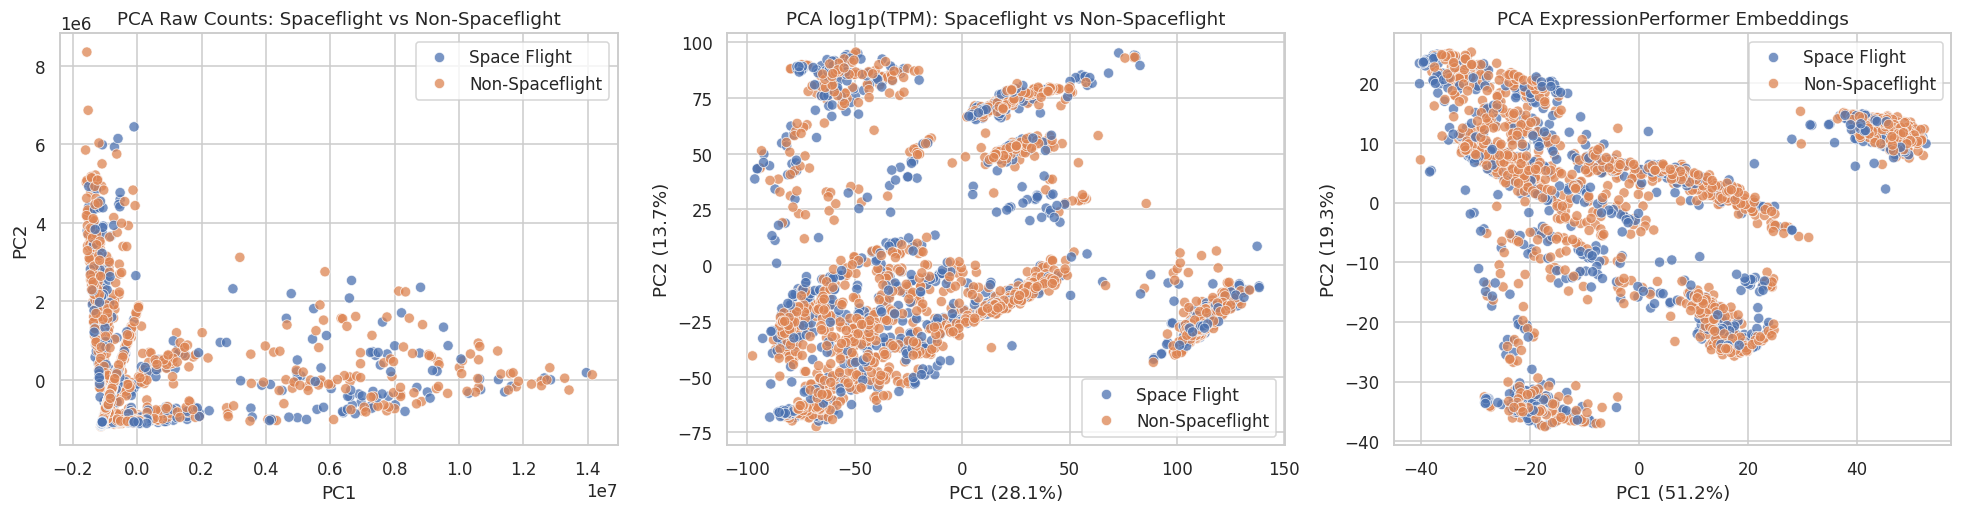

In [8]:
sample_embs_subset = extract_transcriptome_embeddings(
    X_sub,
    model=model,
    aggregate_type="all",
    batch_size=16,
    device=device,
).numpy()

X_raw = X_sub_counts
X_pca_raw = PCA(n_components=2).fit_transform(X_raw)
pca_log = PCA(n_components=2)
X_pca_log = pca_log.fit_transform(X_sub)
pca_emb = PCA(n_components=2)
X_pca_emb = pca_emb.fit_transform(sample_embs_subset)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(x=X_pca_raw[:, 0], y=X_pca_raw[:, 1], hue=labels, alpha=0.75, s=45, ax=axes[0])
axes[0].set_title("PCA Raw Counts: Spaceflight vs Non-Spaceflight")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

sns.scatterplot(x=X_pca_log[:, 0], y=X_pca_log[:, 1], hue=labels, alpha=0.75, s=45, ax=axes[1])
axes[1].set_title("PCA log1p(TPM): Spaceflight vs Non-Spaceflight")
axes[1].set_xlabel(f"PC1 ({pca_log.explained_variance_ratio_[0]:.1%})")
axes[1].set_ylabel(f"PC2 ({pca_log.explained_variance_ratio_[1]:.1%})")

sns.scatterplot(x=X_pca_emb[:, 0], y=X_pca_emb[:, 1], hue=labels, alpha=0.75, s=45, ax=axes[2])
axes[2].set_title("PCA ExpressionPerformer Embeddings")
axes[2].set_xlabel(f"PC1 ({pca_emb.explained_variance_ratio_[0]:.1%})")
axes[2].set_ylabel(f"PC2 ({pca_emb.explained_variance_ratio_[1]:.1%})")

plt.tight_layout()
plt.show()

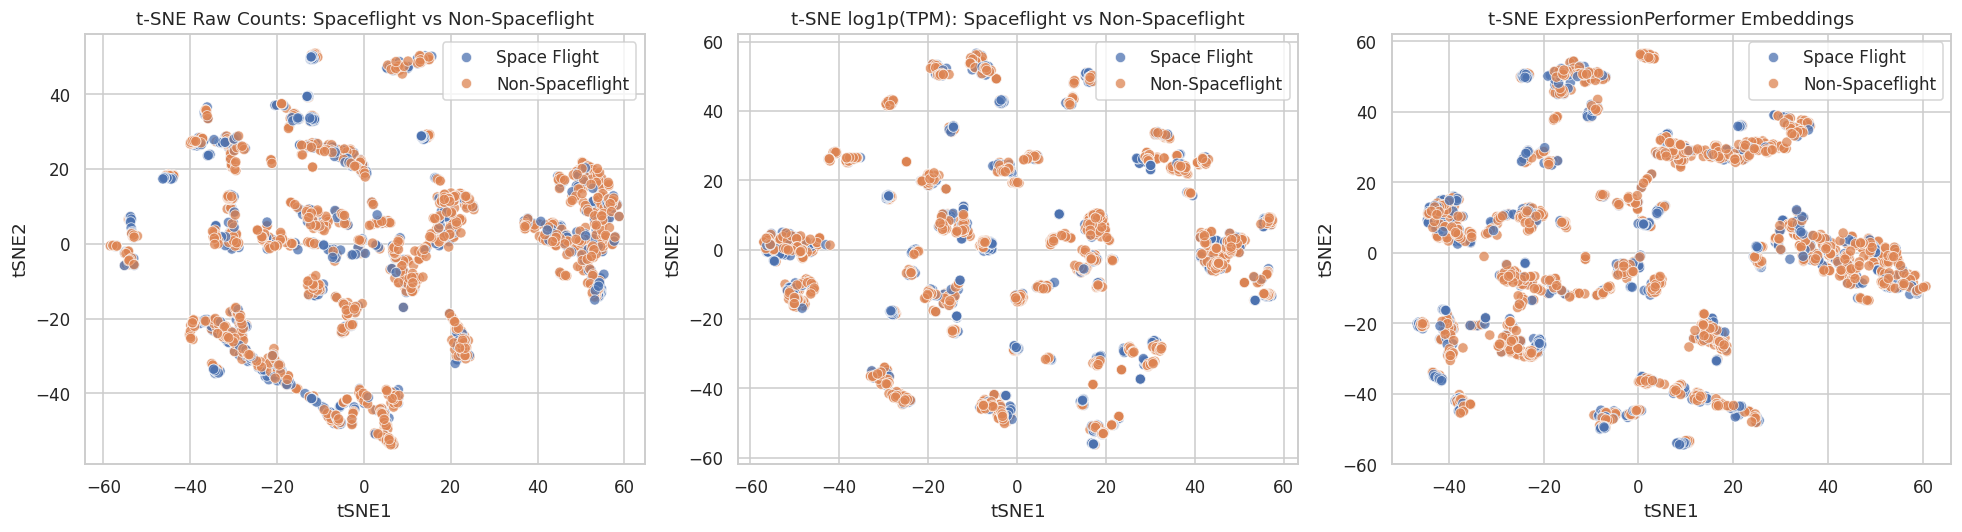

In [9]:
tsne_raw = TSNE(n_components=2, perplexity=30, learning_rate="auto", init="random", random_state=42)
X_tsne_raw = tsne_raw.fit_transform(X_raw)

tsne_log = TSNE(n_components=2, perplexity=30, learning_rate="auto", init="random", random_state=42)
X_tsne_log = tsne_log.fit_transform(X_sub)

tsne_emb = TSNE(n_components=2, perplexity=30, learning_rate="auto", init="random", random_state=42)
X_tsne_emb = tsne_emb.fit_transform(sample_embs_subset)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(x=X_tsne_raw[:, 0], y=X_tsne_raw[:, 1], hue=labels, alpha=0.75, s=45, ax=axes[0])
axes[0].set_title("t-SNE Raw Counts: Spaceflight vs Non-Spaceflight")
axes[0].set_xlabel("tSNE1")
axes[0].set_ylabel("tSNE2")

sns.scatterplot(x=X_tsne_log[:, 0], y=X_tsne_log[:, 1], hue=labels, alpha=0.75, s=45, ax=axes[1])
axes[1].set_title("t-SNE log1p(TPM): Spaceflight vs Non-Spaceflight")
axes[1].set_xlabel("tSNE1")
axes[1].set_ylabel("tSNE2")

sns.scatterplot(x=X_tsne_emb[:, 0], y=X_tsne_emb[:, 1], hue=labels, alpha=0.75, s=45, ax=axes[2])
axes[2].set_title("t-SNE ExpressionPerformer Embeddings")
axes[2].set_xlabel("tSNE1")
axes[2].set_ylabel("tSNE2")

plt.tight_layout()
plt.show()

In [10]:
def eval_model(features, y, name, n_splits=5):
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    clf = make_pipeline(
        StandardScaler(),
        RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    )
    scores = cross_val_score(clf, features, y, cv=cv, scoring="f1_macro")
    return {
        "features": name,
        "f1_macro_mean": float(scores.mean()),
        "f1_macro_std": float(scores.std()),
    }

pca_dim = min(64, X_sub.shape[0] - 1, X_sub.shape[1])
X_pca64 = PCA(n_components=pca_dim, random_state=42).fit_transform(X_sub)

results = pd.DataFrame(
    [
        eval_model(sample_embs_subset, labels, "ExpressionPerformer Embeddings"),
        eval_model(X_sub, labels, "log1p(TPM)"),
        eval_model(X_pca64, labels, f"PCA({pca_dim}) on log1p(TPM)"),
    ]
).sort_values("f1_macro_mean", ascending=False)

results

,features,f1_macro_mean,f1_macro_std
1,log1p(TPM),0.729137,0.019608
2,PCA(64) on log1p(TPM),0.711671,0.026231
0,ExpressionPerformer Embeddings,0.657983,0.012683


In [11]:

# ── Cell 9: Study-aware evaluation (GroupKFold) + Linear probe ──────────────
# GroupKFold prevents train/test from sharing the same study accession,
# giving a truer picture of cross-study generalisation.
# Linear probe (logistic regression) reveals whether the embedding space
# is linearly organised around the spaceflight signal.

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
from sklearn.metrics import f1_score as sk_f1


def eval_model_grouped(features, y, groups, name, n_splits=5):
    """RandomForest with GroupKFold by study accession."""
    gkf = GroupKFold(n_splits=n_splits)
    clf = make_pipeline(
        StandardScaler(),
        RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    )
    scores = cross_val_score(clf, features, y, cv=gkf, scoring="f1_macro", groups=groups)
    return {"features": name, "f1_macro_mean": float(scores.mean()), "f1_macro_std": float(scores.std())}


def eval_model_linear(features, y, name, n_splits=5):
    """Logistic regression linear probe."""
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    clf = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42),
    )
    scores = cross_val_score(clf, features, y, cv=cv, scoring="f1_macro")
    return {"features": name, "f1_macro_mean": float(scores.mean()), "f1_macro_std": float(scores.std())}


groups = meta["id.accession"].to_numpy()
pca_dim_g = min(64, X_sub.shape[0] - 1, X_sub.shape[1])
X_pca64_g = PCA(n_components=pca_dim_g, random_state=42).fit_transform(X_sub)

print("=== GroupKFold by study accession (study-aware, no data leakage) ===")
results_grouped = pd.DataFrame([
    eval_model_grouped(X_sub, labels, groups, "log1p(TPM)"),
    eval_model_grouped(X_pca64_g, labels, groups, f"PCA({pca_dim_g}) on log1p(TPM)"),
    eval_model_grouped(sample_embs_subset, labels, groups, "ExpressionPerformer Embeddings"),
]).sort_values("f1_macro_mean", ascending=False)
display(results_grouped)

print("\n=== Linear probe — logistic regression (tests linear separability) ===")
results_linear = pd.DataFrame([
    eval_model_linear(X_sub, labels, "log1p(TPM)"),
    eval_model_linear(X_pca64_g, labels, f"PCA({pca_dim_g}) on log1p(TPM)"),
    eval_model_linear(sample_embs_subset, labels, "ExpressionPerformer Embeddings"),
]).sort_values("f1_macro_mean", ascending=False)
display(results_linear)


=== GroupKFold by study accession (study-aware, no data leakage) ===


,features,f1_macro_mean,f1_macro_std
0,log1p(TPM),0.620785,0.064942
1,PCA(64) on log1p(TPM),0.596989,0.056612
2,ExpressionPerformer Embeddings,0.548362,0.039019



=== Linear probe — logistic regression (tests linear separability) ===


,features,f1_macro_mean,f1_macro_std
0,log1p(TPM),0.805493,0.012536
2,ExpressionPerformer Embeddings,0.678846,0.010614
1,PCA(64) on log1p(TPM),0.648127,0.018207


Computing low-label regime curves (this may take ~2-3 min)...


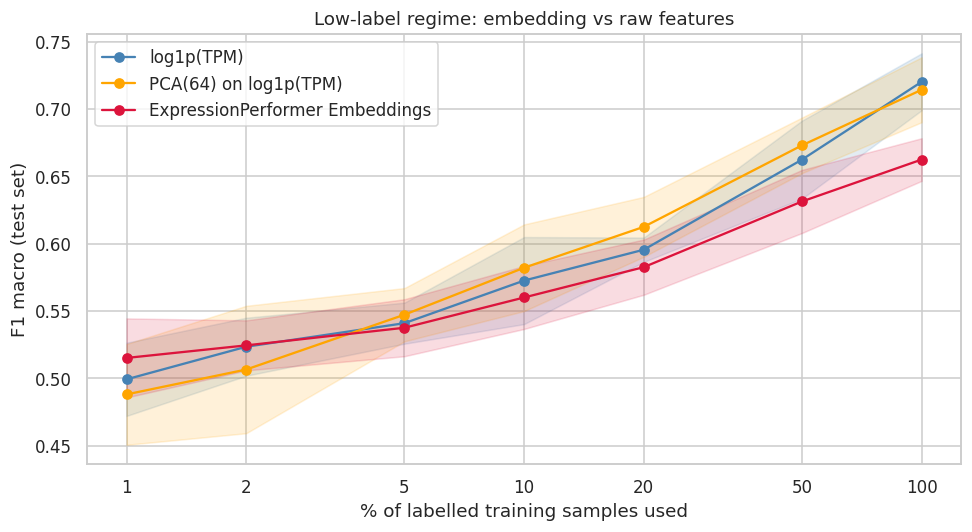

In [12]:

# ── Cell 10: Low-label regime curve ─────────────────────────────────────────
# Classic pretraining diagnostic: if embeddings capture biologically
# meaningful structure, they should outperform raw features when the
# number of labelled samples is small.

from sklearn.model_selection import StratifiedShuffleSplit

FRACTIONS = [0.01, 0.02, 0.05, 0.10, 0.20, 0.50, 1.00]
N_SEEDS = 8


def low_label_eval(features, y, fractions=FRACTIONS, n_seeds=N_SEEDS):
    records = []
    for frac in fractions:
        fold_scores = []
        for seed in range(n_seeds):
            sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=seed)
            (train_idx, test_idx) = next(sss.split(features, y))
            X_tr, X_te = features[train_idx], features[test_idx]
            y_tr, y_te = y[train_idx], y[test_idx]

            # Stratified subsample of training set
            rng = np.random.default_rng(seed)
            sub = []
            for cls in np.unique(y_tr):
                cls_idx = np.where(y_tr == cls)[0]
                n_use = max(1, int(len(cls_idx) * frac))
                sub.extend(rng.choice(cls_idx, size=min(n_use, len(cls_idx)), replace=False))
            sub = np.array(sub)

            clf = make_pipeline(
                StandardScaler(),
                RandomForestClassifier(n_estimators=100, random_state=seed, n_jobs=-1),
            )
            clf.fit(X_tr[sub], y_tr[sub])
            fold_scores.append(sk_f1(y_te, clf.predict(X_te), average="macro"))
        records.append({"label_fraction": frac, "f1_mean": np.mean(fold_scores), "f1_std": np.std(fold_scores)})
    return pd.DataFrame(records)


print("Computing low-label regime curves (this may take ~2-3 min)...")
ll_raw = low_label_eval(X_sub, labels)
ll_emb = low_label_eval(sample_embs_subset, labels)
ll_pca = low_label_eval(X_pca64_g, labels)

fig, ax = plt.subplots(figsize=(9, 5))
for df, name, color in [
    (ll_raw, "log1p(TPM)",                      "steelblue"),
    (ll_pca, f"PCA({pca_dim_g}) on log1p(TPM)", "orange"),
    (ll_emb, "ExpressionPerformer Embeddings",  "crimson"),
]:
    ax.plot(df["label_fraction"] * 100, df["f1_mean"], marker="o", label=name, color=color)
    ax.fill_between(
        df["label_fraction"] * 100,
        df["f1_mean"] - df["f1_std"],
        df["f1_mean"] + df["f1_std"],
        alpha=0.15, color=color,
    )

ax.set_xlabel("% of labelled training samples used")
ax.set_ylabel("F1 macro (test set)")
ax.set_title("Low-label regime: embedding vs raw features")
ax.set_xscale("log")
ax.set_xticks([1, 2, 5, 10, 20, 50, 100])
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.legend()
plt.tight_layout()
show_figure(fig)


Running vanilla ML benchmark (GroupKFold by study accession)...

Feature set: Raw Counts | shape=(2101, 15165)
  Decision Tree        -> 0.5629 ± 0.0281
  Random Forest        -> 0.5714 ± 0.0339
  Extra Trees          -> 0.5725 ± 0.0421
  AdaBoost             -> 0.4650 ± 0.0561
  Logistic Regression  -> 0.6358 ± 0.0691


/home/walt/.local/lib/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/walt/.local/lib/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/walt/.local/lib/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/walt/.local/lib/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/walt/.local/lib/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


  Linear SVM           -> 0.6175 ± 0.0614


/home/walt/.local/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:250: LinAlgWarning: Ill-conditioned matrix (rcond=1.89172e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/home/walt/.local/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:250: LinAlgWarning: Ill-conditioned matrix (rcond=1.74122e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/home/walt/.local/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:250: LinAlgWarning: Ill-conditioned matrix (rcond=1.67694e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/home/walt/.local/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:250: LinAlgWarning: Ill-conditioned matrix (rcond=1.74661e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/home/walt/.local/lib/python3.10/site-packages/s

  Ridge Classifier     -> 0.6012 ± 0.0602
  KNN                  -> 0.5503 ± 0.0277

Feature set: TPM | shape=(2101, 15165)
  Decision Tree        -> 0.5962 ± 0.0423
  Random Forest        -> 0.5548 ± 0.0347
  Extra Trees          -> 0.5638 ± 0.0428
  AdaBoost             -> 0.4616 ± 0.0761
  Logistic Regression  -> 0.6450 ± 0.0805


...

/home/walt/.local/lib/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/walt/.local/lib/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/walt/.local/lib/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/walt/.local/lib/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/walt/.local/lib/python3.10/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


  Linear SVM           -> 0.6517 ± 0.0524


/home/walt/.local/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:250: LinAlgWarning: Ill-conditioned matrix (rcond=4.18673e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/home/walt/.local/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:250: LinAlgWarning: Ill-conditioned matrix (rcond=4.61993e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/home/walt/.local/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:250: LinAlgWarning: Ill-conditioned matrix (rcond=4.72533e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/home/walt/.local/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:250: LinAlgWarning: Ill-conditioned matrix (rcond=4.7022e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/home/walt/.local/lib/python3.10/site-packages/sk

  Ridge Classifier     -> 0.6439 ± 0.0594
  KNN                  -> 0.5280 ± 0.0193

Feature set: Sample Embeddings | shape=(2101, 512)
  Decision Tree        -> 0.5201 ± 0.0216
  Random Forest        -> 0.5141 ± 0.0235
  Extra Trees          -> 0.5191 ± 0.0240
  AdaBoost             -> 0.3863 ± 0.0203
  Logistic Regression  -> 0.5632 ± 0.0553
  Linear SVM           -> 0.5647 ± 0.0471
  Ridge Classifier     -> 0.5609 ± 0.0448
  KNN                  -> 0.5182 ± 0.0268

=== Vanilla ML benchmark results (ranked) ===


,feature_set,model,f1_mean,f1_std,status
20,log1p(TPM),Logistic Regression,0.653761,0.053834,ok
21,log1p(TPM),Linear SVM,0.651679,0.052354,ok
12,TPM,Logistic Regression,0.644957,0.080485,ok
22,log1p(TPM),Ridge Classifier,0.643945,0.059379,ok
4,Raw Counts,Logistic Regression,0.635826,0.069101,ok
13,TPM,Linear SVM,0.635288,0.076638,ok
14,TPM,Ridge Classifier,0.620615,0.081162,ok
5,Raw Counts,Linear SVM,0.617492,0.061395,ok
6,Raw Counts,Ridge Classifier,0.601225,0.060151,ok
8,TPM,Decision Tree,0.596243,0.042307,ok


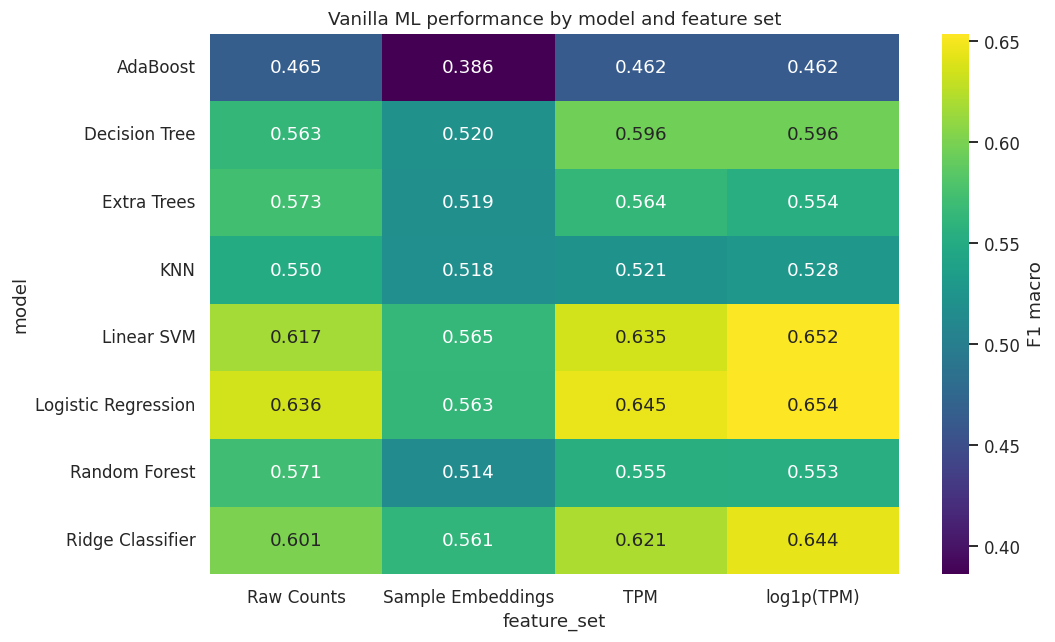

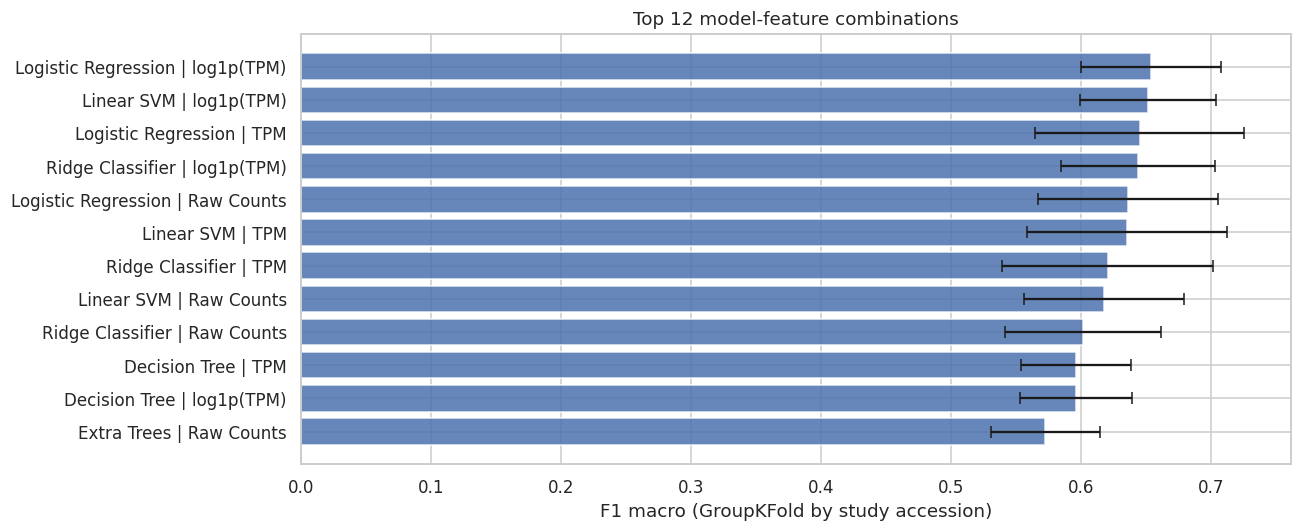

In [ ]:
# # ── Vanilla ML benchmark: raw vs TPM vs log1p vs embeddings ───────────────────
# # Goal: compare straightforward ML models on multiple feature spaces for the
# # spaceflight classification task using study-aware splits.

# from sklearn.ensemble import AdaBoostClassifier, ExtraTreesClassifier
# from sklearn.linear_model import LogisticRegression, RidgeClassifier
# from sklearn.model_selection import GroupKFold
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.svm import LinearSVC
# from sklearn.tree import DecisionTreeClassifier

# feature_sets = {
#     "Raw Counts": X_sub_counts,
#     "TPM": X_sub_tpm,
#     "log1p(TPM)": X_sub,
#     "Sample Embeddings": sample_embs_subset,
# }

# model_specs = {
#     "Decision Tree": lambda: DecisionTreeClassifier(max_depth=20, min_samples_leaf=5, random_state=42),
#     "Random Forest": lambda: RandomForestClassifier(
#         n_estimators=400,
#         class_weight="balanced_subsample",
#         n_jobs=-1,
#         random_state=42,
#     ),
#     "Extra Trees": lambda: ExtraTreesClassifier(
#         n_estimators=400,
#         class_weight="balanced_subsample",
#         n_jobs=-1,
#         random_state=42,
#     ),
#     "AdaBoost": lambda: AdaBoostClassifier(n_estimators=300, learning_rate=0.05, random_state=42),
#     "Logistic Regression": lambda: make_pipeline(
#         StandardScaler(),
#         LogisticRegression(max_iter=3000, class_weight="balanced", random_state=42),
#     ),
#     "Linear SVM": lambda: make_pipeline(
#         StandardScaler(),
#         LinearSVC(class_weight="balanced", random_state=42),
#     ),
#     "Ridge Classifier": lambda: make_pipeline(
#         StandardScaler(),
#         RidgeClassifier(class_weight="balanced", random_state=42),
#     ),
#     "KNN": lambda: make_pipeline(
#         StandardScaler(),
#         KNeighborsClassifier(n_neighbors=25, weights="distance", metric="euclidean"),
#     ),
# }

# groups = meta["id.accession"].to_numpy()
# gkf = GroupKFold(n_splits=5)

# bench_rows = []

# print("Running vanilla ML benchmark (GroupKFold by study accession)...")
# for feat_name, X_feat in feature_sets.items():
#     print(f"\nFeature set: {feat_name} | shape={X_feat.shape}")
#     for model_name, model_builder in model_specs.items():
#         try:
#             clf = model_builder()
#             scores = cross_val_score(
#                 clf,
#                 X_feat,
#                 labels,
#                 cv=gkf,
#                 groups=groups,
#                 scoring="f1_macro",
#             )
#             row = {
#                 "feature_set": feat_name,
#                 "model": model_name,
#                 "f1_mean": float(scores.mean()),
#                 "f1_std": float(scores.std()),
#                 "status": "ok",
#             }
#             print(f"  {model_name:20s} -> {row['f1_mean']:.4f} ± {row['f1_std']:.4f}")
#         except Exception as exc:
#             row = {
#                 "feature_set": feat_name,
#                 "model": model_name,
#                 "f1_mean": np.nan,
#                 "f1_std": np.nan,
#                 "status": f"failed: {str(exc)[:120]}",
#             }
#             print(f"  {model_name:20s} -> FAILED")
#         bench_rows.append(row)

# bench_df = pd.DataFrame(bench_rows).sort_values("f1_mean", ascending=False, na_position="last")
# print("\n=== Vanilla ML benchmark results (ranked) ===")
# display(bench_df)

# # Heatmap for quick visual comparison.
# heat_df = bench_df[bench_df["status"] == "ok"].pivot(index="model", columns="feature_set", values="f1_mean")
# fig, ax = plt.subplots(figsize=(10, 6))
# sns.heatmap(heat_df, annot=True, fmt=".3f", cmap="viridis", cbar_kws={"label": "F1 macro"}, ax=ax)
# ax.set_title("Vanilla ML performance by model and feature set")
# plt.tight_layout()
# show_figure(fig)

# # Compact top-12 bar chart.
# top_n = 12
# top_df = bench_df[bench_df["status"] == "ok"].head(top_n).copy()
# top_df["label"] = top_df["model"] + " | " + top_df["feature_set"]
# fig, ax = plt.subplots(figsize=(12, 5))
# ax.barh(top_df["label"][::-1], top_df["f1_mean"][::-1], xerr=top_df["f1_std"][::-1], capsize=4, alpha=0.85)
# ax.set_xlabel("F1 macro (GroupKFold by study accession)")
# ax.set_title(f"Top {top_n} model-feature combinations")
# plt.tight_layout()
# show_figure(fig)


tissue   features  n_spaceflight  n_non_spaceflight  f1_macro_mean  f1_macro_std
 colon log1p(TPM)             28                 65       0.530880      0.127739
 colon Embeddings             28                 65       0.454663      0.084208
 heart log1p(TPM)             26                 63       0.565104      0.106258
 heart Embeddings             26                 63       0.629894      0.083005
kidney log1p(TPM)             68                196       0.593293      0.045243
kidney Embeddings             68                196       0.530441      0.076794
 liver log1p(TPM)            125                267       0.748675      0.067884
 liver Embeddings            125                267       0.695662      0.078747
  lung log1p(TPM)             30                 56       0.589279      0.153468
  lung Embeddings             30                 56       0.506875      0.168804
muscle log1p(TPM)             50                 67       0.910656      0.040012
muscle Embeddings           

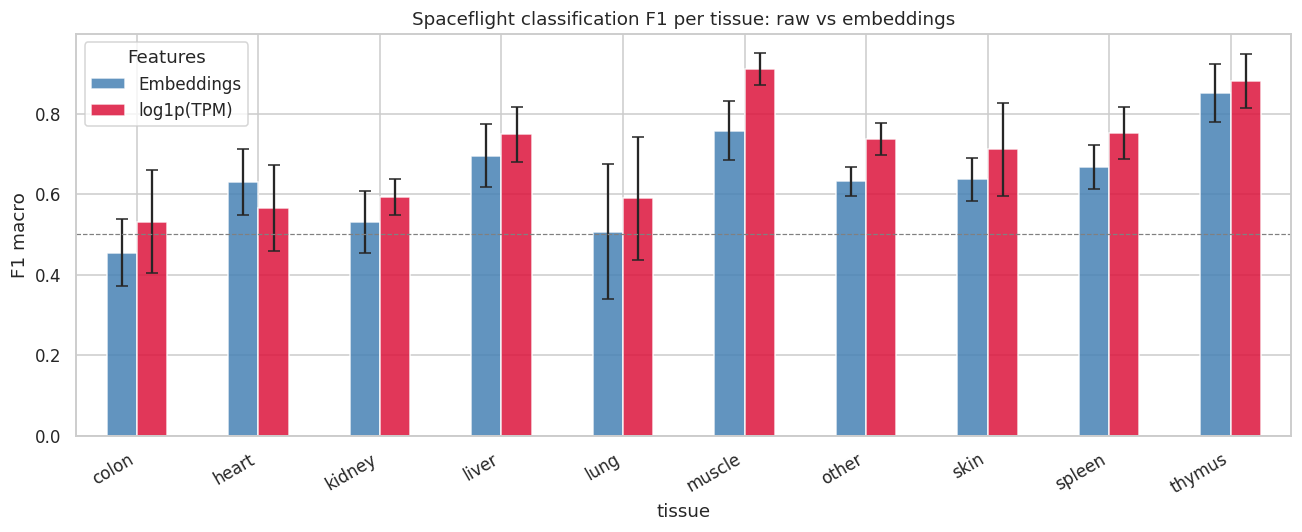

In [13]:

# ── Cell 11: Tissue-stratified comparison ────────────────────────────────────
# The model was trained on many tissues. If it is generalising spaceflight
# biology it should show consistent (or higher) embedding performance
# relative to raw across tissues — not just aggregate.

TISSUE_PATTERNS = {
    "liver":       ["liver", "lobe of liver"],
    "kidney":      ["kidney"],
    "spleen":      ["spleen"],
    "skin":        ["skin"],
    "muscle":      ["soleus", "quadriceps", "muscle"],
    "lung":        ["lung"],
    "thymus":      ["thymus"],
    "colon":       ["colon"],
    "heart":       ["heart"],
    "bone_marrow": ["bone marrow"],
}

def assign_tissue(name_str):
    s = str(name_str).lower()
    for tissue, patterns in TISSUE_PATTERNS.items():
        if any(p in s for p in patterns):
            return tissue
    return "other"


tissue_col = meta["study.characteristics.material type"].apply(assign_tissue).to_numpy()
tissue_series = pd.Series(tissue_col, index=meta.index)

MIN_PER_CLASS = 20  # need enough of each label in each tissue

tissue_records = []
for tissue in sorted(set(tissue_col)):
    mask = tissue_col == tissue
    t_labels = labels[mask]
    n_sp  = int((t_labels == "Space Flight").sum())
    n_ns  = int((t_labels == "Non-Spaceflight").sum())
    if n_sp < MIN_PER_CLASS or n_ns < MIN_PER_CLASS:
        continue

    t_raw = X_sub[mask]
    t_emb = sample_embs_subset[mask]

    for feat, name in [(t_raw, "log1p(TPM)"), (t_emb, "Embeddings")]:
        res = eval_model(feat, t_labels, name)
        tissue_records.append({
            "tissue": tissue,
            "features": name,
            "n_spaceflight": n_sp,
            "n_non_spaceflight": n_ns,
            "f1_macro_mean": res["f1_macro_mean"],
            "f1_macro_std":  res["f1_macro_std"],
        })

tissue_df = pd.DataFrame(tissue_records)
print(tissue_df.to_string(index=False))

# Bar chart: embeddings vs raw per tissue
pivot = tissue_df.pivot(index="tissue", columns="features", values="f1_macro_mean")
pivot_std = tissue_df.pivot(index="tissue", columns="features", values="f1_macro_std")

ax = pivot.plot(kind="bar", yerr=pivot_std, figsize=(12, 5), capsize=4,
                color=["steelblue", "crimson"], alpha=0.85)
ax.set_ylabel("F1 macro")
ax.set_title("Spaceflight classification F1 per tissue: raw vs embeddings")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
ax.legend(title="Features")
ax.axhline(0.5, ls="--", color="grey", lw=0.8, label="chance")
plt.tight_layout()
plt.show()


Extracting per-gene hidden states for 100 samples (50 spaceflight, 50 non-spaceflight)…

Top genes by embedding shift (spaceflight vs non-spaceflight):


,gene,emb_shift,rank
0,SCAND1,14.193954,1
1,PRR12,13.528646,2
2,FSCN1,13.342148,3
3,PDLIM7,13.063904,4
4,MAP3K10,13.036980,5
5,FOXP4,12.886646,6
6,TTYH3,12.838223,7
7,CRYBA4,12.665663,8
8,PPARD,12.583430,9
9,NCOR2,12.522849,10



Bottom 20 genes by embedding shift (least class separation):


,gene,emb_shift,rank_from_bottom
0,ACTRT3,2.198634,1
1,ACTL9,2.267005,2
2,ACTL7B,2.296817,3
3,ACTRT2,2.304290,4
4,ACTL7A,2.332006,5
5,ADAM29,2.358678,6
6,ACKR4,2.379173,7
7,ACTL10,2.380678,8
8,ADAM28,2.387120,9
9,ADAM2,2.421300,10


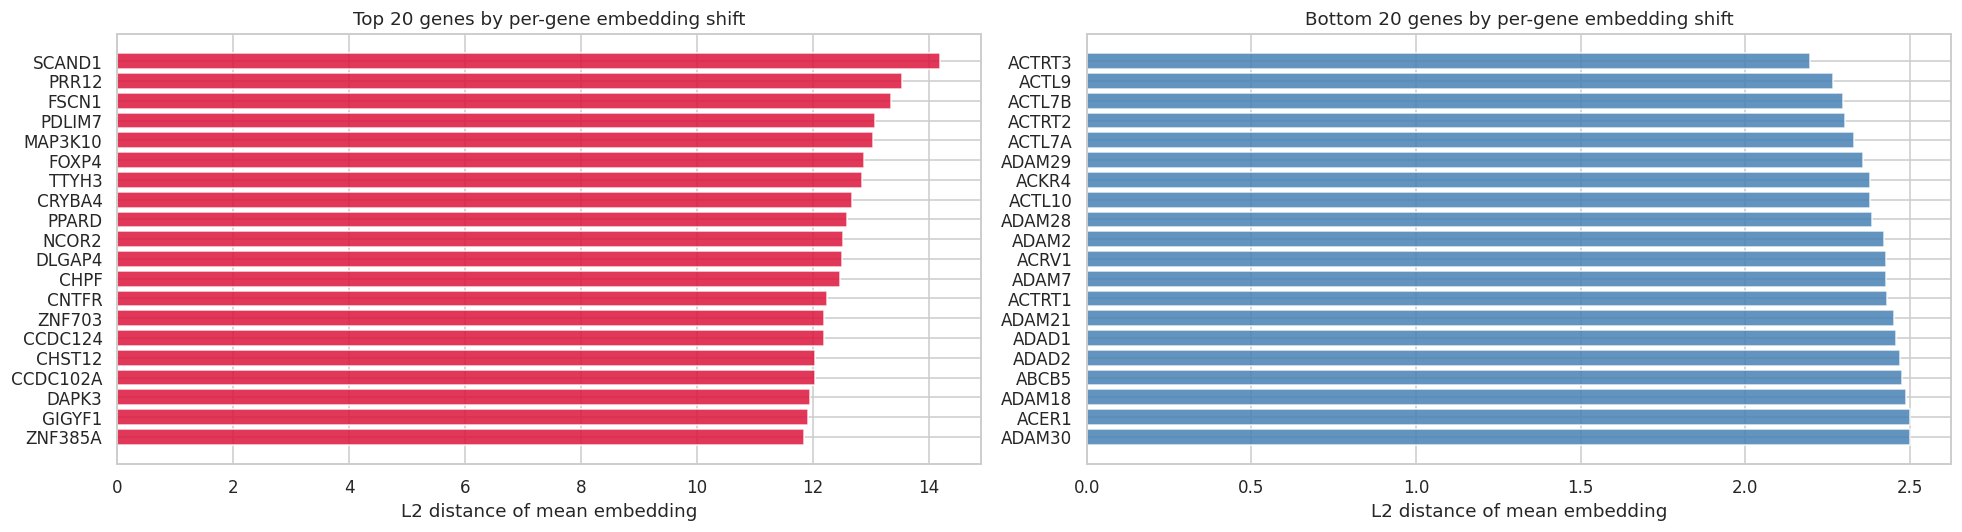


=== Known spaceflight gene enrichment in top embedding shifts ===
  radiation_stress      0/8 genes in top 40:  | ranks: []
  muscle_atrophy        0/8 genes in top 40:  | ranks: []
  immune_dysregul       0/5 genes in top 40:  | ranks: []
  oxidative_stress      0/8 genes in top 40:  | ranks: []
  circadian             0/7 genes in top 40:  | ranks: []
  bone_resorption       0/7 genes in top 40:  | ranks: []


In [17]:

# ── Cell 12: Per-gene embedding shift (spaceflight vs non-spaceflight) ───────
# The transformer returns [B, G, 512] hidden states.
# If the model has learned spaceflight biology, the mean hidden state for
# spaceflight samples and non-spaceflight samples should diverge most
# strongly at known spaceflight-response genes (radiation stress, muscle
# atrophy, immune dysregulation, oxidative stress, circadian disruption).
#
# We use a balanced subset (50 of each class) for speed.

N_SUBSET = 50

rng_sub = np.random.default_rng(0)
sp_idx  = rng_sub.choice(np.where(labels == "Space Flight")[0],    size=min(N_SUBSET, (labels == "Space Flight").sum()),    replace=False)
ns_idx  = rng_sub.choice(np.where(labels == "Non-Spaceflight")[0], size=min(N_SUBSET, (labels == "Non-Spaceflight").sum()), replace=False)
sub_idx = np.concatenate([sp_idx, ns_idx])
sub_labels = labels[sub_idx]


def extract_per_gene_hidden(expr_arr, model, batch_size=8, device=device):
    """Returns float32 ndarray [N, G, hidden_dim] — before pooling."""
    loader = DataLoader(TensorDataset(torch.tensor(expr_arr, dtype=torch.float32)),
                        batch_size=batch_size, shuffle=False)
    parts = []
    model.eval()
    with torch.no_grad():
        for (xb,) in loader:
            parts.append(encode_hidden_states(model, xb.to(device)).cpu().numpy())
    return np.concatenate(parts, axis=0)


print(f"Extracting per-gene hidden states for {len(sub_idx)} samples "
      f"({(sub_labels=='Space Flight').sum()} spaceflight, "
      f"{(sub_labels=='Non-Spaceflight').sum()} non-spaceflight)…")
per_gene = extract_per_gene_hidden(X_sub[sub_idx], model)   # [100, G, 512]

sp_mask = sub_labels == "Space Flight"
ns_mask = sub_labels == "Non-Spaceflight"
mean_sp = per_gene[sp_mask].mean(axis=0)   # [G, 512]
mean_ns = per_gene[ns_mask].mean(axis=0)   # [G, 512]
gene_shift_l2 = np.linalg.norm(mean_sp - mean_ns, axis=1)  # [G]

top_k = 40
top_idx = np.argsort(gene_shift_l2)[::-1][:top_k]
gene_shift_df = pd.DataFrame({
    "gene":       [gene_order[i] for i in top_idx],
    "emb_shift":  gene_shift_l2[top_idx],
    "rank":       range(1, top_k + 1),
})
print("\nTop genes by embedding shift (spaceflight vs non-spaceflight):")
display(gene_shift_df.head(20))

# Also show genes with the smallest class-separation shift.
bottom_k = 20
bottom_idx = np.argsort(gene_shift_l2)[:bottom_k]
bottom_gene_shift_df = pd.DataFrame({
    "gene":      [gene_order[i] for i in bottom_idx],
    "emb_shift": gene_shift_l2[bottom_idx],
    "rank_from_bottom": range(1, bottom_k + 1),
}).sort_values("emb_shift", ascending=True)
print("\nBottom 20 genes by embedding shift (least class separation):")
display(bottom_gene_shift_df)

# Bar charts: top-20 and bottom-20 for quick visual comparison.
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

top20 = gene_shift_df.head(20)
axes[0].barh(top20["gene"][::-1], top20["emb_shift"][::-1], color="crimson", alpha=0.85)
axes[0].set_xlabel("L2 distance of mean embedding")
axes[0].set_title("Top 20 genes by per-gene embedding shift")

axes[1].barh(bottom_gene_shift_df["gene"][::-1], bottom_gene_shift_df["emb_shift"][::-1], color="steelblue", alpha=0.85)
axes[1].set_xlabel("L2 distance of mean embedding")
axes[1].set_title("Bottom 20 genes by per-gene embedding shift")

plt.tight_layout()
show_figure(fig)

# Cosine similarity to known spaceflight gene set (manual curated list)
KNOWN_SPACEFLIGHT_GENES = {
    "radiation_stress":  ["CDKN1A", "TP53", "GADD45A", "MDM2", "ATM", "H2AX", "PCNA", "RAD51"],
    "muscle_atrophy":    ["TRIM63", "FBXO32", "MSTN", "ACTA1", "MYH7", "IGF1", "MYOD1", "FOXO3"],
    "immune_dysregul":   ["IL6", "TNF", "CXCL10", "CD3E", "CD8A", "IFNG", "IL2", "NFKB1"],
    "oxidative_stress":  ["SOD1", "SOD2", "CAT", "GPX1", "HMOX1", "NFE2L2", "TXNRD1", "PRDX1"],
    "circadian":         ["ARNTL", "CLOCK", "PER1", "PER2", "CRY1", "CRY2", "NR1D1", "TIMELESS"],
    "bone_resorption":   ["RANKL", "TNFSF11", "CTSK", "ACP5", "MMP9", "CALCR", "RUNX2", "SPP1"],
}

gene_to_rank = {g: r for r, g in enumerate(gene_shift_df["gene"].tolist())}
print("\n=== Known spaceflight gene enrichment in top embedding shifts ===")
gene_order_set = set(gene_order)
for pathway, genes in KNOWN_SPACEFLIGHT_GENES.items():
    present = [g for g in genes if g in gene_order_set]
    hits     = [g for g in present if g in gene_to_rank]
    ranks    = sorted(gene_to_rank[g] + 1 for g in hits)
    print(f"  {pathway:20s}  {len(hits)}/{len(present)} genes in top {top_k}: {', '.join(hits)} | ranks: {ranks}")


In [18]:
# Consolidated metrics snapshot for summary/reporting
print("=== Dataset / ingest ===")
print(f"samples={X_sub.shape[0]}, genes={X_sub.shape[1]}")
print(f"class_counts={{'Space Flight': {(labels=='Space Flight').sum()}, 'Non-Spaceflight': {(labels=='Non-Spaceflight').sum()}}}")
if 'ingest_diag' in globals():
    keys = [
        'metadata_rows_initial',
        'metadata_rows_dropped_missing_spaceflight_field',
        'qc_min_nonzero_genes_threshold',
        'samples_seen_before_qc',
        'samples_retained_after_qc',
        'samples_dropped_low_detected_genes',
        'genes_in_samples_not_in_model_list',
        'genes_in_model_list_not_observed_in_samples',
        'observed_gene_fraction_per_sample_mean',
    ]
    print({k: ingest_diag.get(k) for k in keys})

print("\n=== Imputation (simple) ===")
print(imputation_metrics)

print("\n=== Main classification tables ===")
print("results")
print(results[['features','f1_macro_mean','f1_macro_std']].to_string(index=False))
print("\nresults_grouped")
print(results_grouped[['features','f1_macro_mean','f1_macro_std']].to_string(index=False))
print("\nresults_linear")
print(results_linear[['features','f1_macro_mean','f1_macro_std']].to_string(index=False))

print("\n=== Fine-tune benchmark ===")
print(ft_results[['features','f1_macro_mean','f1_macro_std']].to_string(index=False))

print("\n=== Advanced strategies ===")
print(adv_df[['method','f1_mean','f1_std']].to_string(index=False))

print("\n=== Tissue summary (mean F1 over tissues) ===")
if 'tissue_df' in globals() and len(tissue_df):
    print(tissue_df.groupby('features')['f1_macro_mean'].agg(['mean','min','max','count']).to_string())

print("\n=== Low-label summary (selected points) ===")
for name, df in [('raw', ll_raw), ('pca', ll_pca), ('emb', ll_emb)]:
    sel = df[df['label_fraction'].isin([0.01, 0.1, 1.0])][['label_fraction','f1_mean','f1_std']]
    print(f"[{name}]\n{sel.to_string(index=False)}")


=== Dataset / ingest ===
samples=2101, genes=15165
class_counts={'Space Flight': 775, 'Non-Spaceflight': 1326}
{'metadata_rows_initial': 2896, 'metadata_rows_dropped_missing_spaceflight_field': 733, 'qc_min_nonzero_genes_threshold': 14000, 'samples_seen_before_qc': 2108, 'samples_retained_after_qc': 2101, 'samples_dropped_low_detected_genes': 7, 'genes_in_samples_not_in_model_list': 942, 'genes_in_model_list_not_observed_in_samples': 0, 'observed_gene_fraction_per_sample_mean': 0.9004508395904609}

=== Imputation (simple) ===
{'masked_fraction': 0.14998158445266435, 'pearson': 0.8978022892502624, 'spearman': 0.8995069955375938}

=== Main classification tables ===
results
                      features  f1_macro_mean  f1_macro_std
                    log1p(TPM)       0.729137      0.019608
         PCA(64) on log1p(TPM)       0.711671      0.026231
ExpressionPerformer Embeddings       0.657983      0.012683

results_grouped
                      features  f1_macro_mean  f1_macro_std
   

Extracting mean-pooled 512-dim embeddings for all samples...
(same backbone pass as cell 6; ~20-25 min on GPU)
Embeddings shape: (2101, 512)
Classes: {'Non-Spaceflight': np.int64(1326), 'Space Flight': np.int64(775)}

=== Frozen backbone + RF on 512-dim mean-pooled embeddings ===
  Fold 1: F1=0.4845
  Fold 2: F1=0.5331
  Fold 3: F1=0.5160
  Fold 4: F1=0.5238
  Fold 5: F1=0.4657
  -> 0.5046 +- 0.0254

=== Frozen backbone + MLP head (80 max epochs, early stopping) ===
  Fold 1: F1=0.5247
  Fold 2: F1=0.4522
  Fold 3: F1=0.5192
  Fold 4: F1=0.5366
  Fold 5: F1=0.5138
  -> 0.5093 +- 0.0295

(Full fine-tune skipped - set RUN_FULL_FINETUNE=True to enable)

=== Fine-tuning benchmark (GroupKFold by study accession) ===


,features,f1_macro_mean,f1_macro_std
1,Frozen backbone + MLP head (balanced),0.509303,0.029521
0,Frozen backbone + RF (512-dim mean),0.504637,0.025424


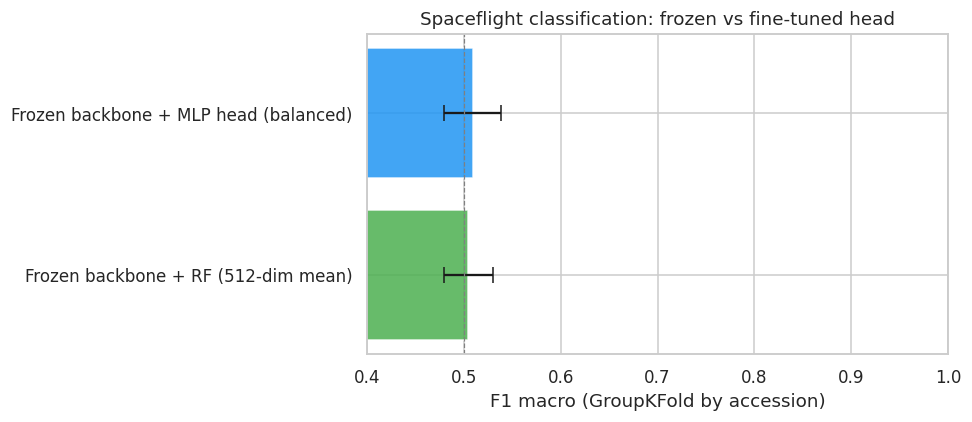

In [15]:

# ── Cell 13: Fine-tuning a classification head (balanced + stabilized) ─────────
# Why fine-tuning can underperform frozen embeddings:
# 1) class imbalance can bias the head toward majority class,
# 2) fixed-epoch training without validation can overfit,
# 3) full FT with tiny labels can drift pretrained features.
#
# This version adds:
# - class-balanced sampling per epoch,
# - fold-internal validation with early stopping,
# - best-checkpoint restore before test scoring,
# - conservative learning rates + gradient clipping for full FT.

import copy
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import f1_score as sk_f1
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import WeightedRandomSampler

RUN_FULL_FINETUNE = False   # flip to True for end-to-end fine-tune
N_EPOCHS_FROZEN   = 80
N_EPOCHS_FULL_FT  = 10
BATCH_SIZE        = 32
EARLY_STOPPING_PATIENCE = 10


# ── 1. Mean-pool all hidden states once (frozen backbone) ────────────────────
class SpaceflightHead(nn.Module):
    """Small MLP classification head: 512 -> 256 -> 64 -> n_classes."""
    def __init__(self, input_dim, n_classes=2, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(input_dim),
            nn.Linear(input_dim, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        return self.net(x)


def extract_mean_pooled(backbone, expr_np, batch_size=32, device=device):
    """Returns float32 Tensor [N, hidden_dim] (mean over gene position)."""
    loader = DataLoader(
        TensorDataset(torch.tensor(expr_np, dtype=torch.float32)),
        batch_size=batch_size,
        shuffle=False,
    )
    parts = []
    backbone.eval()
    with torch.no_grad():
        for (xb,) in loader:
            h = encode_hidden_states(backbone, xb.to(device))  # [B, G, D]
            parts.append(h.mean(dim=1).cpu())
    return torch.cat(parts, dim=0)


def make_balanced_sampler(y_tensor):
    """Weighted sampler that balances classes in each training epoch."""
    y_np = y_tensor.cpu().numpy().astype(int)
    counts = np.bincount(y_np)
    cls_w = 1.0 / np.clip(counts, 1, None)
    sample_w = cls_w[y_np]
    return WeightedRandomSampler(
        weights=torch.tensor(sample_w, dtype=torch.double),
        num_samples=len(y_np),
        replacement=True,
    )


def stratified_inner_split(y_tensor, seed=42, n_splits=5):
    """Train/val split inside each outer fold for early stopping."""
    y_np = y_tensor.cpu().numpy().astype(int)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    tr_inner, val_inner = next(skf.split(np.zeros(len(y_np)), y_np))
    return tr_inner, val_inner


print("Extracting mean-pooled 512-dim embeddings for all samples...")
print("(same backbone pass as cell 6; ~20-25 min on GPU)")
emb_mean = extract_mean_pooled(model, X_sub, batch_size=BATCH_SIZE, device=device)
print(f"Embeddings shape: {tuple(emb_mean.shape)}")


# ── 2. Setup labels + GroupKFold by study accession ───────────────────────────
le = LabelEncoder()
y_enc = torch.tensor(le.fit_transform(labels), dtype=torch.long)
groups = meta["id.accession"].to_numpy()
counts = np.bincount(y_enc.numpy())
print(f"Classes: {dict(zip(le.classes_, counts))}")

gkf = GroupKFold(n_splits=5)
fold_splits = list(gkf.split(X_sub, labels, groups=groups))


# ── 3a. Frozen backbone + RF baseline on 512-dim ──────────────────────────────
print("\n=== Frozen backbone + RF on 512-dim mean-pooled embeddings ===")
emb_np = emb_mean.numpy()
rf_scores = []
for fold, (tr_idx, te_idx) in enumerate(fold_splits):
    clf = make_pipeline(
        StandardScaler(),
        RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1, class_weight="balanced_subsample"),
    )
    clf.fit(emb_np[tr_idx], labels[tr_idx])
    preds = clf.predict(emb_np[te_idx])
    f1 = sk_f1(labels[te_idx], preds, average="macro")
    rf_scores.append(f1)
    print(f"  Fold {fold+1}: F1={f1:.4f}")
print(f"  -> {np.mean(rf_scores):.4f} +- {np.std(rf_scores):.4f}")


# ── 3b. Frozen backbone + MLP head (balanced sampler + early stopping) ───────
print(f"\n=== Frozen backbone + MLP head ({N_EPOCHS_FROZEN} max epochs, early stopping) ===")
mlp_scores = []
for fold, (tr_idx, te_idx) in enumerate(fold_splits):
    emb_fold = emb_mean[tr_idx]
    y_fold = y_enc[tr_idx]
    tr_inner, val_inner = stratified_inner_split(y_fold, seed=42 + fold)

    X_tr = emb_fold[tr_inner]
    y_tr = y_fold[tr_inner]
    X_val = emb_fold[val_inner].to(device)
    y_val = y_fold[val_inner].to(device)

    sampler = make_balanced_sampler(y_tr)
    ds_tr = TensorDataset(X_tr, y_tr)
    loader_tr = DataLoader(ds_tr, batch_size=BATCH_SIZE, sampler=sampler)

    head = SpaceflightHead(emb_mean.shape[1], n_classes=2).to(device)
    optimizer = optim.AdamW(head.parameters(), lr=5e-4, weight_decay=5e-3)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.6, patience=3)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.03)

    best_state = copy.deepcopy(head.state_dict())
    best_val = float("inf")
    best_epoch = 0

    for epoch in range(N_EPOCHS_FROZEN):
        head.train()
        for emb_b, y_b in loader_tr:
            emb_b = emb_b.to(device)
            y_b = y_b.to(device)
            optimizer.zero_grad()
            loss = criterion(head(emb_b), y_b)
            loss.backward()
            optimizer.step()

        head.eval()
        with torch.no_grad():
            val_loss = criterion(head(X_val), y_val).item()
        scheduler.step(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            best_epoch = epoch
            best_state = copy.deepcopy(head.state_dict())
        elif epoch - best_epoch >= EARLY_STOPPING_PATIENCE:
            break

    head.load_state_dict(best_state)
    head.eval()
    emb_te = emb_mean[te_idx].to(device)
    y_te = y_enc[te_idx].numpy()
    with torch.no_grad():
        preds = head(emb_te).argmax(dim=1).cpu().numpy()
    f1 = sk_f1(y_te, preds, average="macro")
    mlp_scores.append(f1)
    print(f"  Fold {fold+1}: F1={f1:.4f}")

print(f"  -> {np.mean(mlp_scores):.4f} +- {np.std(mlp_scores):.4f}")


# ── 3c. Full end-to-end fine-tune (optional, balanced + conservative) ─────────
base_state = copy.deepcopy(model.state_dict())
full_ft_scores = []

if RUN_FULL_FINETUNE:
    print(f"\n=== Full fine-tune: backbone (3e-6) + head (5e-4), {N_EPOCHS_FULL_FT} max epochs ===")
    for fold, (tr_idx, te_idx) in enumerate(fold_splits):
        model.load_state_dict(copy.deepcopy(base_state))
        model = model.to(device)

        X_fold = torch.tensor(X_sub[tr_idx], dtype=torch.float32)
        y_fold = y_enc[tr_idx]
        tr_inner, val_inner = stratified_inner_split(y_fold, seed=123 + fold)

        X_tr = X_fold[tr_inner]
        y_tr = y_fold[tr_inner]
        X_val = X_fold[val_inner].to(device)
        y_val = y_fold[val_inner].to(device)

        sampler = make_balanced_sampler(y_tr)
        ds_tr = TensorDataset(X_tr, y_tr)
        loader_tr = DataLoader(ds_tr, batch_size=BATCH_SIZE, sampler=sampler)

        head = SpaceflightHead(cfg["hidden_dim"], n_classes=2).to(device)
        optimizer = optim.AdamW([
            {"params": model.parameters(), "lr": 3e-6, "weight_decay": 1e-4},
            {"params": head.parameters(),  "lr": 5e-4, "weight_decay": 5e-3},
        ])
        criterion = nn.CrossEntropyLoss(label_smoothing=0.03)

        best_model_state = copy.deepcopy(model.state_dict())
        best_head_state = copy.deepcopy(head.state_dict())
        best_val = float("inf")
        best_epoch = 0

        for epoch in range(N_EPOCHS_FULL_FT):
            model.train()
            head.train()
            for xb, yb in loader_tr:
                xb = xb.to(device)
                yb = yb.to(device)
                optimizer.zero_grad()
                h = encode_hidden_states(model, xb).mean(dim=1)
                loss = criterion(head(h), yb)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                torch.nn.utils.clip_grad_norm_(head.parameters(), max_norm=1.0)
                optimizer.step()

            model.eval()
            head.eval()
            with torch.no_grad():
                h_val = encode_hidden_states(model, X_val).mean(dim=1)
                val_loss = criterion(head(h_val), y_val).item()

            if val_loss < best_val:
                best_val = val_loss
                best_epoch = epoch
                best_model_state = copy.deepcopy(model.state_dict())
                best_head_state = copy.deepcopy(head.state_dict())
            elif epoch - best_epoch >= EARLY_STOPPING_PATIENCE:
                break

        model.load_state_dict(best_model_state)
        head.load_state_dict(best_head_state)
        model.eval()
        head.eval()

        X_te_t = torch.tensor(X_sub[te_idx], dtype=torch.float32)
        with torch.no_grad():
            h_te = extract_mean_pooled(model, X_te_t.numpy(), batch_size=BATCH_SIZE, device=device).to(device)
            preds = head(h_te).argmax(dim=1).cpu().numpy()

        f1 = sk_f1(y_enc[te_idx].numpy(), preds, average="macro")
        full_ft_scores.append(f1)
        print(f"  Fold {fold+1}: F1={f1:.4f}")

    model.load_state_dict(base_state)
    print(f"  -> {np.mean(full_ft_scores):.4f} +- {np.std(full_ft_scores):.4f}")
else:
    print("\n(Full fine-tune skipped - set RUN_FULL_FINETUNE=True to enable)")


# ── 4. Summary table ─────────────────────────────────────────────────────────
rows = [
    {"features": "Frozen backbone + RF (512-dim mean)",  "f1_macro_mean": np.mean(rf_scores),  "f1_macro_std": np.std(rf_scores)},
    {"features": "Frozen backbone + MLP head (balanced)", "f1_macro_mean": np.mean(mlp_scores), "f1_macro_std": np.std(mlp_scores)},
]
if full_ft_scores:
    rows.append({"features": "Full fine-tune (balanced)", "f1_macro_mean": np.mean(full_ft_scores), "f1_macro_std": np.std(full_ft_scores)})

ft_results = pd.DataFrame(rows).sort_values("f1_macro_mean", ascending=False)
print("\n=== Fine-tuning benchmark (GroupKFold by study accession) ===")
display(ft_results)

fig, ax = plt.subplots(figsize=(9, 4))
bar_labels = ft_results["features"].tolist()
bar_means = ft_results["f1_macro_mean"].tolist()
bar_stds = ft_results["f1_macro_std"].tolist()
colors = ["#2196F3", "#4CAF50", "#F44336"][:len(bar_labels)]
ax.barh(bar_labels[::-1], bar_means[::-1], xerr=bar_stds[::-1], color=colors[::-1], alpha=0.85, capsize=5)
ax.set_xlabel("F1 macro (GroupKFold by accession)")
ax.set_title("Spaceflight classification: frozen vs fine-tuned head")
ax.axvline(0.5, ls="--", color="grey", lw=0.8, label="chance")
ax.set_xlim(0.4, 1.0)
plt.tight_layout()
plt.show()


=== A. Multi-scale pooling (mean + max + std) + RF ===
  Fold 1: F1=0.4721
  Fold 2: F1=0.5143
  Fold 3: F1=0.5389
  Fold 4: F1=0.5342
  Fold 5: F1=0.5013
  -> 0.5122 ± 0.0242

=== B. Gene-shift weighted pooling + RF ===
  Fold 1: F1=0.4782
  Fold 2: F1=0.5298
  Fold 3: F1=0.5365
  Fold 4: F1=0.5543
  Fold 5: F1=0.4871
  -> 0.5172 ± 0.0294

=== C. Top-100 gene attention head (backbone frozen) ===
  Pre-extracting top-100 gene positions for 2101 samples (one pass)...
  Cache shape: (2101, 100, 512)
  Fold 1: F1=0.4969
  Fold 2: F1=0.4835
  Fold 3: F1=0.5424
  Fold 4: F1=0.5116
  Fold 5: F1=0.5802
  -> 0.5229 ± 0.0347

=== Advanced strategy summary (GroupKFold by study accession) ===


,method,f1_mean,f1_std
3,"Top-100 gene attention head, frozen [C]",0.522923,0.034691
2,Gene-shift weighted pool + RF [B],0.517189,0.029447
1,Multi-scale pool (mean|max|std) + RF [A],0.512166,0.024210
0,Mean-pool + RF (Cell 13 baseline),0.504637,0.025424


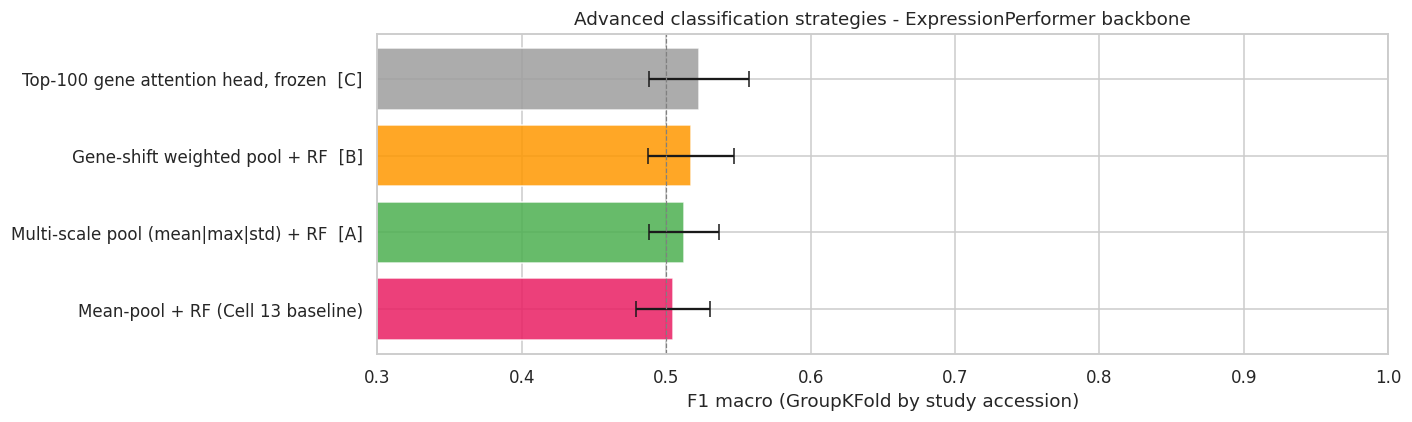

In [16]:

# ── Cell 14: Advanced strategies to demonstrate model potential ────────────────
#
# Three approaches that exploit the pretrained backbone progressively deeper:
#
# A) Multi-scale pooling + RF (no training)
#    Concatenate mean + max + std of all gene hidden states.
#    Wider, richer frozen feature than mean alone.
#
# B) Gene-shift weighted pooling + RF (no training)
#    Pool hidden states weighted by each gene's L2 embedding shift between
#    spaceflight / non-spaceflight conditions (computed in Cell 12).
#    Biology-informed weighting with zero gradient steps.
#
# C) Top-K gene attention head (backbone frozen, attention learned)
#    Pre-extract hidden states at the top-100 most shifted gene positions —
#    compact enough to cache in memory — then train a soft-attention pooling
#    + MLP head over just those positions. One backbone pass; fast training;
#    biologically interpretable attention weights.
#
# All evaluated under GroupKFold by study accession (honest cross-study F1).

import copy
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import WeightedRandomSampler

HIDDEN_DIM = cfg["hidden_dim"]


def _make_balanced_sampler(y_tensor):
    y_np = y_tensor.cpu().numpy().astype(int)
    cls_w = 1.0 / np.bincount(y_np).clip(1)
    sample_w = cls_w[y_np]
    return WeightedRandomSampler(
        weights=torch.tensor(sample_w, dtype=torch.double),
        num_samples=len(y_np), replacement=True,
    )


# ── A. Multi-scale pooling (mean | max | std) + RF ───────────────────────────
print("=== A. Multi-scale pooling (mean + max + std) + RF ===")


def extract_multiscale_emb(backbone, expr_np, batch_size=32, device=device):
    """[N, 3×D] — mean, max, std of gene-position hidden states concatenated."""
    loader = DataLoader(
        TensorDataset(torch.tensor(expr_np, dtype=torch.float32)),
        batch_size=batch_size, shuffle=False,
    )
    parts = []
    backbone.eval()
    with torch.no_grad():
        for (xb,) in loader:
            h = encode_hidden_states(backbone, xb.to(device))   # [B, G, D]
            parts.append(torch.cat([h.mean(1), h.amax(1), h.std(1)], dim=1).cpu())
    return torch.cat(parts, dim=0).numpy()


emb_multi = extract_multiscale_emb(model, X_sub, device=device)
ms_scores = []
for fold, (tr_idx, te_idx) in enumerate(fold_splits):
    clf = make_pipeline(
        StandardScaler(),
        RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1,
                               class_weight="balanced_subsample"),
    )
    clf.fit(emb_multi[tr_idx], labels[tr_idx])
    f1 = sk_f1(labels[te_idx], clf.predict(emb_multi[te_idx]), average="macro")
    ms_scores.append(f1)
    print(f"  Fold {fold+1}: F1={f1:.4f}")
print(f"  -> {np.mean(ms_scores):.4f} ± {np.std(ms_scores):.4f}")


# ── B. Gene-shift weighted pooling + RF ──────────────────────────────────────
print("\n=== B. Gene-shift weighted pooling + RF ===")

shift_w = torch.tensor(gene_shift_l2 / (gene_shift_l2.sum() + 1e-12), dtype=torch.float32)


def extract_shift_weighted_emb(backbone, expr_np, weights, batch_size=32, device=device):
    """[N, D] — hidden states pooled by per-gene spaceflight-shift weights."""
    loader = DataLoader(
        TensorDataset(torch.tensor(expr_np, dtype=torch.float32)),
        batch_size=batch_size, shuffle=False,
    )
    parts = []
    backbone.eval()
    with torch.no_grad():
        for (xb,) in loader:
            h = encode_hidden_states(backbone, xb.to(device))   # [B, G, D]
            w = weights.to(device)[None, :, None]               # [1, G, 1]
            parts.append((h * w).sum(dim=1).cpu())              # [B, D]
    return torch.cat(parts, dim=0).numpy()


emb_sw = extract_shift_weighted_emb(model, X_sub, shift_w, device=device)
sw_scores = []
for fold, (tr_idx, te_idx) in enumerate(fold_splits):
    clf = make_pipeline(
        StandardScaler(),
        RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1,
                               class_weight="balanced_subsample"),
    )
    clf.fit(emb_sw[tr_idx], labels[tr_idx])
    f1 = sk_f1(labels[te_idx], clf.predict(emb_sw[te_idx]), average="macro")
    sw_scores.append(f1)
    print(f"  Fold {fold+1}: F1={f1:.4f}")
print(f"  -> {np.mean(sw_scores):.4f} ± {np.std(sw_scores):.4f}")


# ── C. Top-K gene attention head (backbone frozen, one pass, fast training) ──
print("\n=== C. Top-100 gene attention head (backbone frozen) ===")

TOP_K_GENES = 100
# np.argsort(...)[::-1] creates a negative-stride view; copy() makes it contiguous.
topk_gene_idx = np.argsort(gene_shift_l2)[::-1][:TOP_K_GENES].copy().astype(np.int64)


def extract_topk_gene_hidden(backbone, expr_np, gene_indices, batch_size=32, device=device):
    """[N, K, D] — hidden states at selected gene positions. One backbone pass."""
    gene_indices = np.asarray(gene_indices, dtype=np.int64).copy()
    loader = DataLoader(
        TensorDataset(torch.tensor(expr_np, dtype=torch.float32)),
        batch_size=batch_size, shuffle=False,
    )
    parts = []
    backbone.eval()
    with torch.no_grad():
        for (xb,) in loader:
            h = encode_hidden_states(backbone, xb.to(device))   # [B, G, D]
            parts.append(h[:, gene_indices, :].cpu())           # [B, K, D]
    return torch.cat(parts, dim=0)   # [N, K, D] on CPU


print(f"  Pre-extracting top-{TOP_K_GENES} gene positions for {len(X_sub)} samples (one pass)...")
emb_topk = extract_topk_gene_hidden(model, X_sub, topk_gene_idx, device=device)
print(f"  Cache shape: {tuple(emb_topk.shape)}")


class TopKAttnHead(nn.Module):
    """Soft attention over K gene positions -> layer-norm -> MLP classifier."""
    def __init__(self, gene_dim, n_classes=2, hidden=128, dropout=0.2):
        super().__init__()
        self.gate = nn.Linear(gene_dim, 1, bias=False)
        self.norm = nn.LayerNorm(gene_dim)
        self.clf = nn.Sequential(
            nn.Linear(gene_dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, n_classes),
        )

    def forward(self, h):                               # h: [B, K, D]
        attn = torch.softmax(self.gate(h), dim=1)      # [B, K, 1]
        pooled = (h * attn).sum(dim=1)                 # [B, D]
        return self.clf(self.norm(pooled))


N_EPOCHS_ATT = 80
att_scores = []

for fold, (tr_idx, te_idx) in enumerate(fold_splits):
    y_fold = y_enc[tr_idx]
    tr_inner, val_inner = stratified_inner_split(y_fold, seed=77 + fold)

    H_fold = emb_topk[tr_idx]               # [N_fold, K, D] CPU
    H_tr = H_fold[tr_inner]
    H_va = H_fold[val_inner].to(device)
    y_tr_t = y_fold[tr_inner]
    y_va_t = y_fold[val_inner].to(device)

    loader_att = DataLoader(
        TensorDataset(H_tr, y_tr_t),
        batch_size=BATCH_SIZE,
        sampler=_make_balanced_sampler(y_tr_t),
    )

    head = TopKAttnHead(HIDDEN_DIM, n_classes=2).to(device)
    opt = optim.AdamW(head.parameters(), lr=5e-4, weight_decay=5e-3)
    sch = optim.lr_scheduler.ReduceLROnPlateau(opt, "min", factor=0.6, patience=5)
    crit = nn.CrossEntropyLoss(label_smoothing=0.03)

    best_state = copy.deepcopy(head.state_dict())
    best_val = float("inf")
    best_ep = 0

    for epoch in range(N_EPOCHS_ATT):
        head.train()
        for H_b, y_b in loader_att:
            H_b = H_b.to(device)
            y_b = y_b.to(device)
            opt.zero_grad()
            crit(head(H_b), y_b).backward()
            opt.step()

        head.eval()
        with torch.no_grad():
            vl = crit(head(H_va), y_va_t).item()
        sch.step(vl)

        if vl < best_val:
            best_val = vl
            best_ep = epoch
            best_state = copy.deepcopy(head.state_dict())
        elif epoch - best_ep >= EARLY_STOPPING_PATIENCE:
            break

    head.load_state_dict(best_state)
    head.eval()
    with torch.no_grad():
        preds = head(emb_topk[te_idx].to(device)).argmax(1).cpu().numpy()
    f1 = sk_f1(y_enc[te_idx].numpy(), preds, average="macro")
    att_scores.append(f1)
    print(f"  Fold {fold+1}: F1={f1:.4f}")
print(f"  -> {np.mean(att_scores):.4f} ± {np.std(att_scores):.4f}")


# ── Summary comparison ────────────────────────────────────────────────────────
adv_rows = [
    {"method": "Mean-pool + RF (Cell 13 baseline)",
     "f1_mean": np.mean(rf_scores), "f1_std": np.std(rf_scores)},
    {"method": "Multi-scale pool (mean|max|std) + RF  [A]",
     "f1_mean": np.mean(ms_scores), "f1_std": np.std(ms_scores)},
    {"method": "Gene-shift weighted pool + RF  [B]",
     "f1_mean": np.mean(sw_scores), "f1_std": np.std(sw_scores)},
    {"method": f"Top-{TOP_K_GENES} gene attention head, frozen  [C]",
     "f1_mean": np.mean(att_scores), "f1_std": np.std(att_scores)},
]
adv_df = pd.DataFrame(adv_rows).sort_values("f1_mean", ascending=False)
print("\n=== Advanced strategy summary (GroupKFold by study accession) ===")
display(adv_df)

fig, ax = plt.subplots(figsize=(13, 4))
clrs = ["#9E9E9E", "#FF9800", "#4CAF50", "#E91E63"]
lb_adv = adv_df["method"].tolist()
ms_adv = adv_df["f1_mean"].tolist()
ss_adv = adv_df["f1_std"].tolist()
ax.barh(lb_adv[::-1], ms_adv[::-1], xerr=ss_adv[::-1],
        color=clrs[::-1], alpha=0.85, capsize=5)
ax.axvline(0.5, ls="--", color="grey", lw=0.8, label="chance")
ax.set_xlabel("F1 macro (GroupKFold by study accession)")
ax.set_title("Advanced classification strategies - ExpressionPerformer backbone")
ax.set_xlim(0.3, 1.0)
plt.tight_layout()
show_figure(fig)


Computing contrastive gradient × input saliency...

Top spaceflight-attributed genes (contrastive):


,gene,contrast_saliency,spaceflight_saliency,non_spaceflight_saliency,rank
0,AATK,0.048252,0.218504,0.170252,1
1,AAAS,0.027453,0.136211,0.108759,2
2,ABCD3,0.022831,0.089477,0.066646,3
3,ABCC8,0.020383,0.066462,0.046079,4
4,ABCA7,0.019945,0.187646,0.167701,5
5,ACTA1,0.017777,0.046620,0.028843,6
6,AARS2,0.015781,0.101638,0.085858,7
7,AACS,0.015583,0.217405,0.201822,8
8,ACYP2,0.014508,0.116455,0.101947,9
9,ABHD8,0.014203,0.084289,0.070086,10


Tie diagnostic: unique values in top-50 (rounded 1e-10) = 50/50
First-letter enrichment diagnostic (top 30 vs background):


,top30_frac,background_frac
A,0.90,0.076954
C,0.06,0.103660
F,0.02,0.038642
B,0.02,0.021497
S,0.00,0.107287
P,0.00,0.094098
T,0.00,0.083218
M,0.00,0.062644
R,0.00,0.054138
N,0.00,0.045170


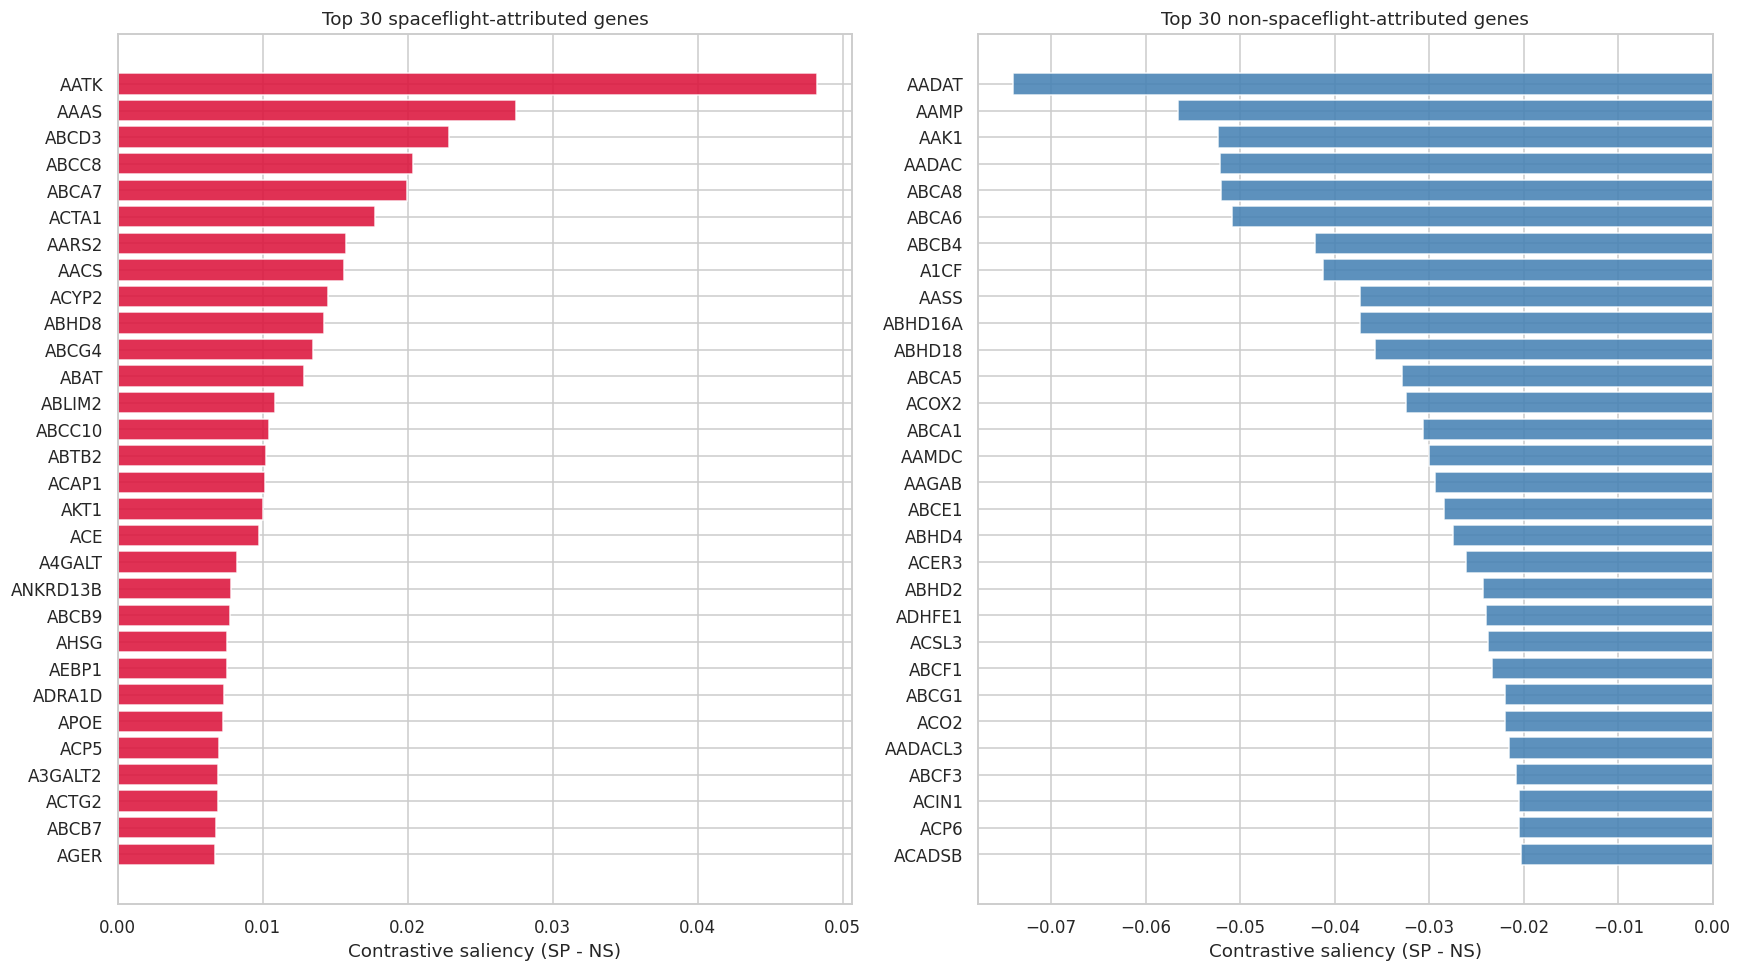

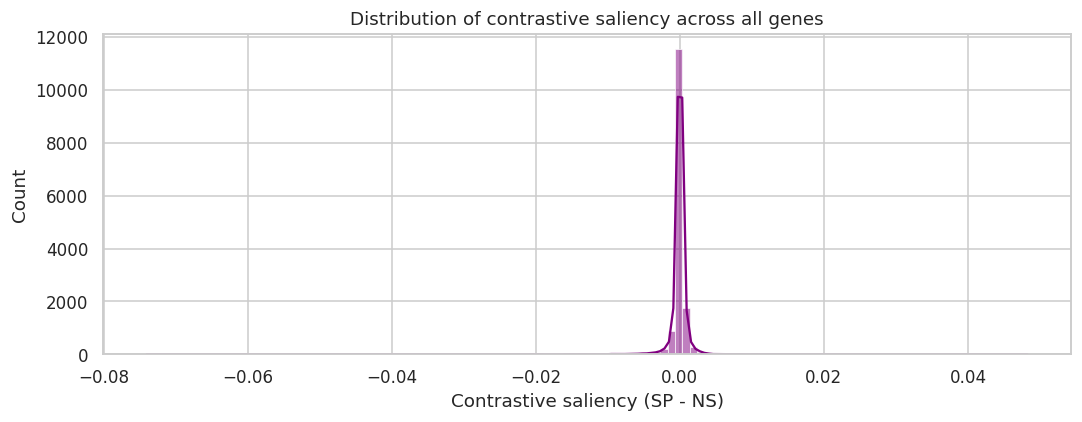

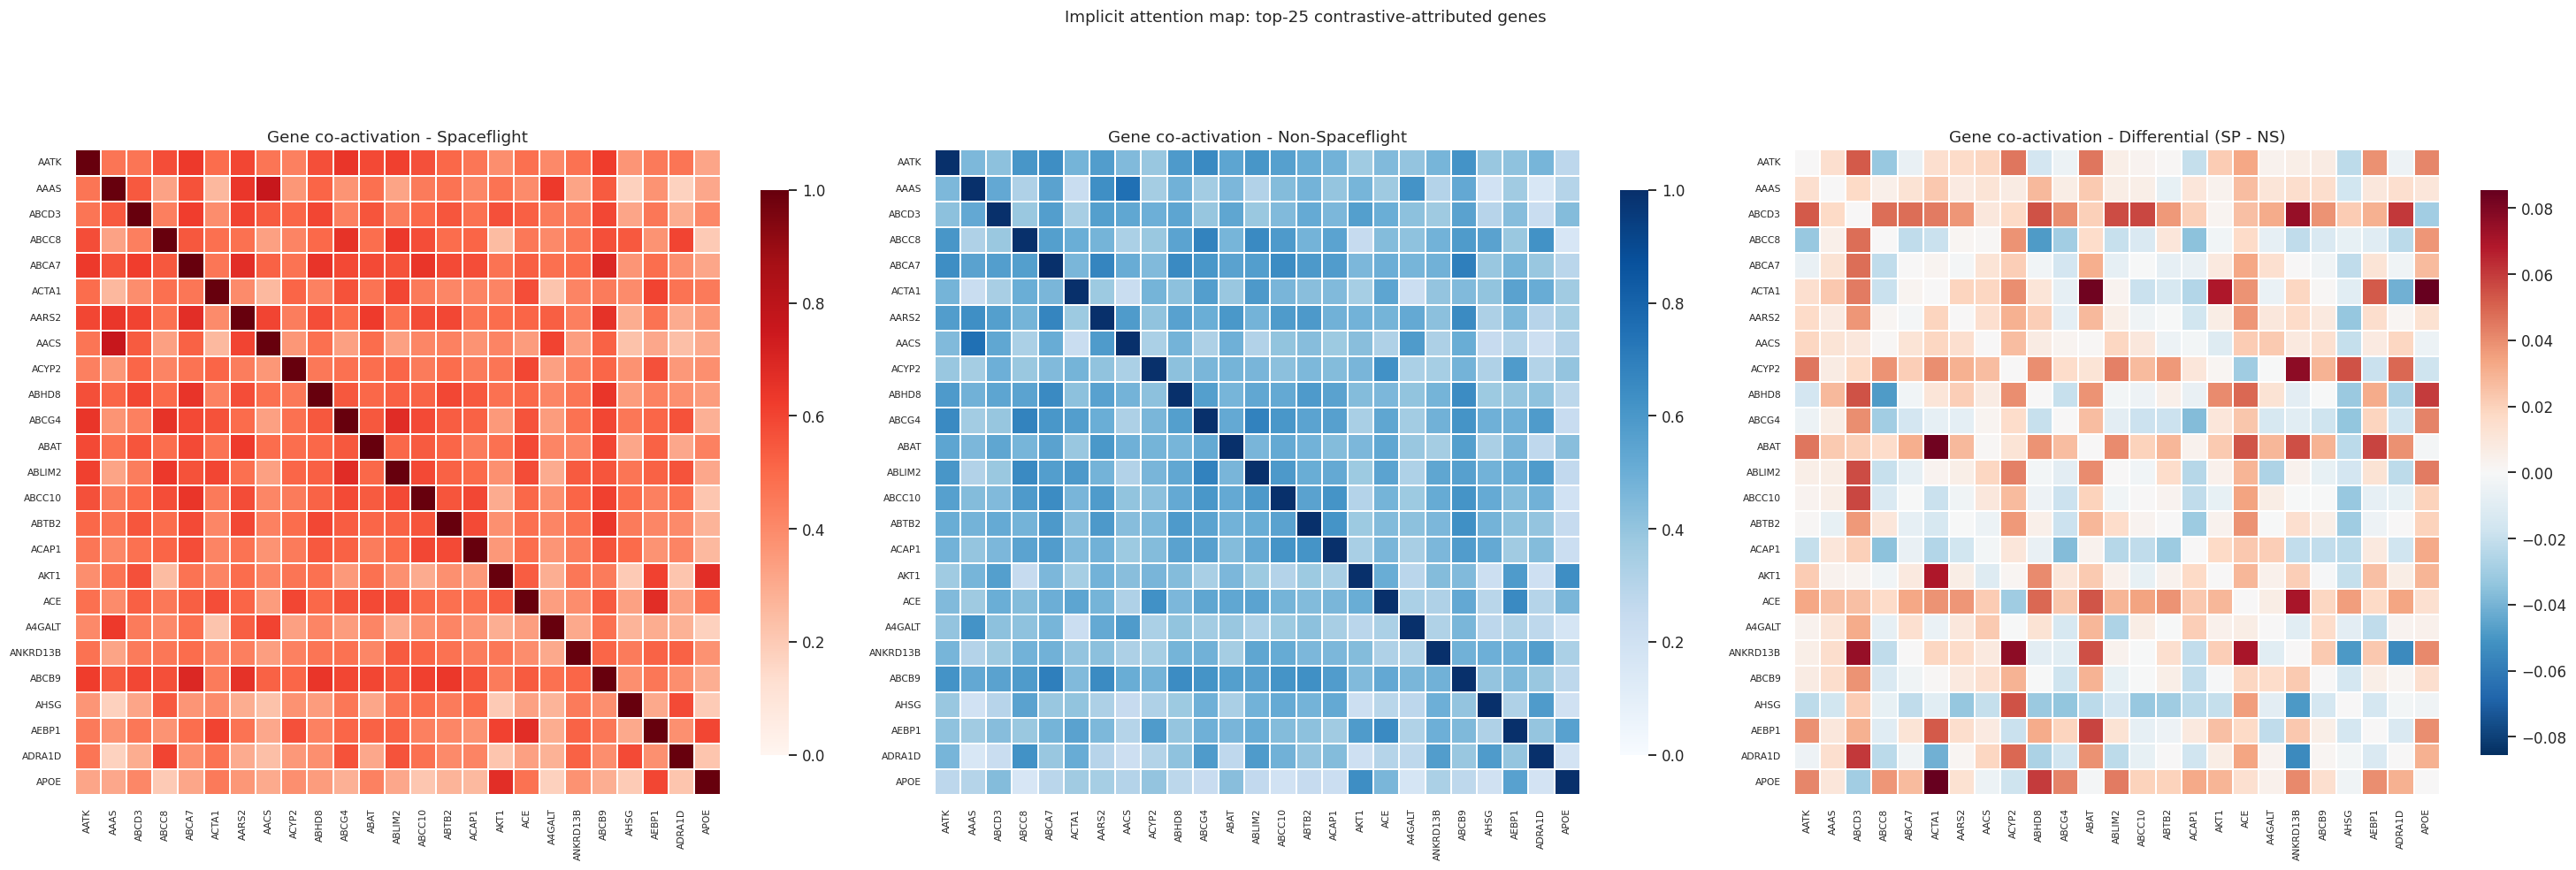


Interpretation:
  - If one letter dominates top genes and tie diagnostic is low-unique, ranking is unstable.
  - Contrastive saliency (SP-NS) reduces generic high-saliency genes and surfaces class-specific ones.
  - Differential co-activation heatmap highlights gene pairs specifically coordinated in spaceflight.


In [22]:

# ── Attention Attribution / Interpretability (contrastive, no manual gene list) ──
# Why this update:
# - If many genes have nearly identical saliency, np.argsort can surface genes by
#   index order (often alphabetical in canonical gene lists), creating a false
#   "all-A genes" pattern.
# - We therefore use CONTRASTIVE attribution:
#     score = (spaceflight saliency) - (non-spaceflight saliency)
#   which highlights genes uniquely important for spaceflight.

# ── Pre-computation: spaceflight direction in embedding space ──────────────────
gene_idx_of = {g: i for i, g in enumerate(gene_order)}

d_sf = (mean_sp.mean(axis=0) - mean_ns.mean(axis=0)).astype(np.float32)  # [D]
d_sf /= np.linalg.norm(d_sf) + 1e-8
d_sf_t = torch.tensor(d_sf, device=device)


def grad_x_input_saliency(sample_indices, direction_vec, batch_size=8):
    """Average |grad * input| per gene for a sample subset."""
    grad_acc = np.zeros(len(gene_order), dtype=np.float64)

    model.eval()
    for i in range(0, len(sample_indices), batch_size):
        batch_idx = sample_indices[i : i + batch_size]
        x = torch.tensor(X_sub[batch_idx], dtype=torch.float32, device=device)
        x.requires_grad_(True)

        # Forward with grad tracking
        gene_ids = torch.arange(x.shape[1], device=device)
        gene_emb = model.gene_embedding(gene_ids)
        ree_emb = model.ree(x)
        h = gene_emb.unsqueeze(0) + ree_emb
        for layer in model.layers:
            rfs = layer.attention.sample_rfs(device)
            h = layer.full_forward(h, rfs)

        # Scalar objective: projection onto direction vector
        score = (h.mean(dim=1) * direction_vec).sum(dim=1).sum()
        score.backward()

        with torch.no_grad():
            grad_acc += (x.grad * x).abs().cpu().numpy().sum(axis=0)

    return (grad_acc / max(len(sample_indices), 1)).astype(np.float32)


print("Computing contrastive gradient × input saliency...")
SALIENCY_BATCH = 8
saliency_sp = grad_x_input_saliency(sp_idx, d_sf_t, batch_size=SALIENCY_BATCH)
saliency_ns = grad_x_input_saliency(ns_idx, d_sf_t, batch_size=SALIENCY_BATCH)

# Contrastive attribution: positive -> more spaceflight-specific importance
saliency_contrast = saliency_sp - saliency_ns

TOP_SAL = 50
top_up_idx = np.argsort(saliency_contrast)[::-1][:TOP_SAL]
top_dn_idx = np.argsort(saliency_contrast)[:TOP_SAL]

saliency_df = pd.DataFrame({
    "gene": [gene_order[i] for i in top_up_idx],
    "contrast_saliency": saliency_contrast[top_up_idx],
    "spaceflight_saliency": saliency_sp[top_up_idx],
    "non_spaceflight_saliency": saliency_ns[top_up_idx],
    "rank": range(1, TOP_SAL + 1),
})

print("\nTop spaceflight-attributed genes (contrastive):")
display(saliency_df.head(30))

# First-letter diagnostic to catch alphabetical artifacts from ties
top_letters = pd.Series([g[0].upper() if g else "?" for g in saliency_df["gene"]], name="top30")
all_letters = pd.Series([g[0].upper() if g else "?" for g in gene_order], name="all_genes")
letter_diag = pd.concat([
    top_letters.value_counts(normalize=True).rename("top30_frac"),
    all_letters.value_counts(normalize=True).rename("background_frac"),
], axis=1).fillna(0.0).sort_values("top30_frac", ascending=False)

# Tie diagnostic: if too many nearly equal values, ranking can be unstable
rounded_top = np.round(saliency_df["contrast_saliency"].to_numpy(), 10)
unique_top = int(np.unique(rounded_top).size)
print(f"Tie diagnostic: unique values in top-{TOP_SAL} (rounded 1e-10) = {unique_top}/{TOP_SAL}")
print("First-letter enrichment diagnostic (top 30 vs background):")
display(letter_diag.head(10))

# Up/down charts
DISPLAY_N = 30
up_df = saliency_df.head(DISPLAY_N)
dn_df = pd.DataFrame({
    "gene": [gene_order[i] for i in top_dn_idx[:DISPLAY_N]],
    "contrast_saliency": saliency_contrast[top_dn_idx[:DISPLAY_N]],
})

fig, axes = plt.subplots(1, 2, figsize=(16, 9))
axes[0].barh(up_df["gene"][::-1], up_df["contrast_saliency"][::-1], color="crimson", alpha=0.88)
axes[0].set_xlabel("Contrastive saliency (SP - NS)")
axes[0].set_title(f"Top {DISPLAY_N} spaceflight-attributed genes")

axes[1].barh(dn_df["gene"][::-1], dn_df["contrast_saliency"][::-1], color="steelblue", alpha=0.88)
axes[1].set_xlabel("Contrastive saliency (SP - NS)")
axes[1].set_title(f"Top {DISPLAY_N} non-spaceflight-attributed genes")

plt.tight_layout()
show_figure(fig)

# Distribution check
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(saliency_contrast, bins=120, kde=True, ax=ax, color="purple")
ax.set_title("Distribution of contrastive saliency across all genes")
ax.set_xlabel("Contrastive saliency (SP - NS)")
plt.tight_layout()
show_figure(fig)


# ── Implicit co-activation map from top attributed genes ──────────────────────
TOP_ATT = 25
top_att_idx = top_up_idx[:TOP_ATT]
top_att_genes = [gene_order[i] for i in top_att_idx]

H_top_sp = per_gene[sp_mask][:, top_att_idx, :]   # [N_sp, K, D]
H_top_ns = per_gene[ns_mask][:, top_att_idx, :]   # [N_ns, K, D]


def cosine_sim_matrix(H_batch):
    norms = np.linalg.norm(H_batch, axis=2, keepdims=True) + 1e-8
    H_n = H_batch / norms
    return np.einsum("nid,njd->nij", H_n, H_n).mean(0)


att_sp = cosine_sim_matrix(H_top_sp)
att_ns = cosine_sim_matrix(H_top_ns)
diff_att = att_sp - att_ns

fig, axes = plt.subplots(1, 3, figsize=(27, 9))
_tick_kw = dict(axis="x", rotation=90, labelsize=7)

for _ax, _mat, _cmap, _v, _title in [
    (axes[0], att_sp, "Reds", (0, 1), "Spaceflight"),
    (axes[1], att_ns, "Blues", (0, 1), "Non-Spaceflight"),
    (axes[2], diff_att, "RdBu_r", (-diff_att.max(), diff_att.max()), "Differential (SP - NS)"),
]:
    sns.heatmap(
        _mat,
        xticklabels=top_att_genes,
        yticklabels=top_att_genes,
        vmin=_v[0],
        vmax=_v[1],
        cmap=_cmap,
        ax=_ax,
        square=True,
        linewidths=0.3,
        cbar_kws={"shrink": 0.7},
    )
    _ax.set_title(f"Gene co-activation - {_title}")
    _ax.tick_params(**_tick_kw)
    _ax.tick_params(axis="y", labelsize=7)

plt.suptitle(f"Implicit attention map: top-{TOP_ATT} contrastive-attributed genes", fontsize=12, y=1.01)
plt.tight_layout()
show_figure(fig)

print("\nInterpretation:")
print("  - If one letter dominates top genes and tie diagnostic is low-unique, ranking is unstable.")
print("  - Contrastive saliency (SP-NS) reduces generic high-saliency genes and surfaces class-specific ones.")
print("  - Differential co-activation heatmap highlights gene pairs specifically coordinated in spaceflight.")


Index-bias diagnostics
  Spearman(index, contrast_saliency)       = 0.0443  (p=4.95e-08)
  Spearman(index, |contrast_saliency|)     = -0.6201  (p=0.00e+00)

First-letter enrichment in top 200 genes:


,top_frac,bg_frac,enrichment
A,0.615,0.076954,7.991838
B,0.050,0.021497,2.325920
C,0.195,0.103660,1.881155
D,0.045,0.039499,1.139274
E,0.025,0.031982,0.781701
G,0.030,0.045104,0.665132
F,0.025,0.038642,0.646971
I,0.005,0.026904,0.185846
H,0.005,0.028421,0.175928
M,0.005,0.062644,0.079816


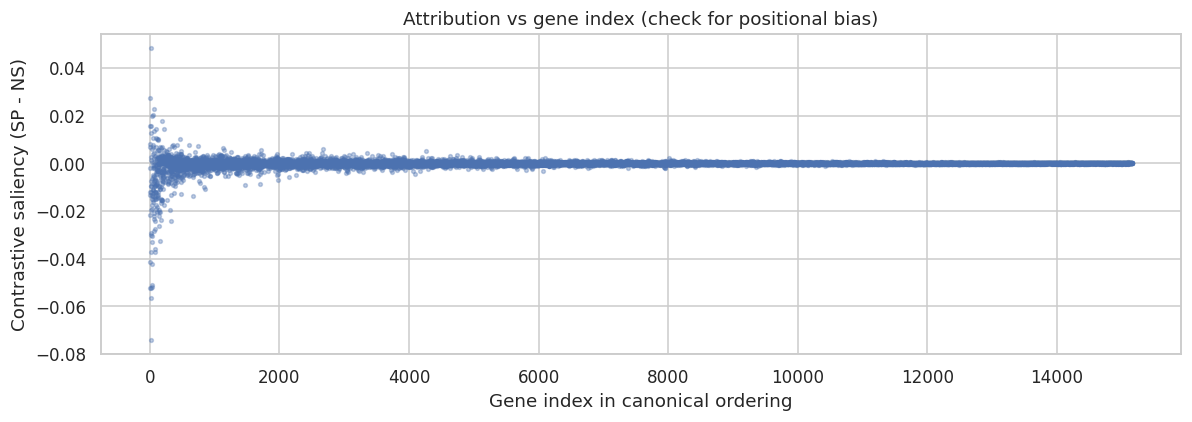

In [23]:
# Diagnostic: check whether contrastive saliency is dominated by gene index / ordering bias
# If gene_order is alphabetical and attribution correlates with index, an A-heavy top list
# can be a positional artifact rather than biology.

from scipy.stats import spearmanr

idx = np.arange(len(gene_order), dtype=np.int64)
abs_contrast = np.abs(saliency_contrast)

rho_signed, p_signed = spearmanr(idx, saliency_contrast)
rho_abs, p_abs = spearmanr(idx, abs_contrast)

print("Index-bias diagnostics")
print(f"  Spearman(index, contrast_saliency)       = {rho_signed:.4f}  (p={p_signed:.2e})")
print(f"  Spearman(index, |contrast_saliency|)     = {rho_abs:.4f}  (p={p_abs:.2e})")

# Top-200 first-letter composition vs background
TOP_K_DIAG = 200
top_idx = np.argsort(saliency_contrast)[::-1][:TOP_K_DIAG]
top_letters = pd.Series([gene_order[i][0].upper() for i in top_idx])
all_letters = pd.Series([g[0].upper() for g in gene_order])

diag_df = pd.concat([
    top_letters.value_counts(normalize=True).rename("top_frac"),
    all_letters.value_counts(normalize=True).rename("bg_frac"),
], axis=1).fillna(0.0)
diag_df["enrichment"] = diag_df["top_frac"] / np.clip(diag_df["bg_frac"], 1e-12, None)
diag_df = diag_df.sort_values("enrichment", ascending=False)

print(f"\nFirst-letter enrichment in top {TOP_K_DIAG} genes:")
display(diag_df.head(10))

# Visualize saliency vs gene index
fig, ax = plt.subplots(figsize=(11, 4))
ax.scatter(idx, saliency_contrast, s=6, alpha=0.35)
ax.set_xlabel("Gene index in canonical ordering")
ax.set_ylabel("Contrastive saliency (SP - NS)")
ax.set_title("Attribution vs gene index (check for positional bias)")
plt.tight_layout()
show_figure(fig)


Top 30 genes by DEBIASED contrastive attribution:


/tmp/ipykernel_96754/618130318.py:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  pd.Series(np.abs(saliency_contrast))


,gene,debiased_score,raw_contrast,local_scale,rank
0,FAM219A,15.267119,0.004991,0.000327,1
1,MTSS2,13.405816,0.002329,0.000174,2
2,COPE,12.985499,0.005922,0.000456,3
3,GAA,11.843959,0.003603,0.000304,4
4,DLGAP4,11.543388,0.004175,0.000362,5
5,UNC5A,11.137142,0.000432,0.000039,6
6,CAVIN3,10.960496,0.005424,0.000495,7
7,ZNF703,10.827846,0.000397,0.000037,8
8,GNB2,10.592685,0.002781,0.000263,9
9,DCTN1,10.313897,0.004063,0.000394,10



First-letter enrichment after debiasing (top 30):


,top30_frac_debiased,background_frac,enrichment
G,0.166667,0.045104,3.695175
D,0.133333,0.039499,3.375626
H,0.066667,0.028421,2.345708
U,0.033333,0.017211,1.936782
F,0.066667,0.038642,1.725256
C,0.166667,0.103660,1.607824
I,0.033333,0.026904,1.238971
Z,0.033333,0.027563,1.209330
M,0.066667,0.062644,1.064211
E,0.033333,0.031982,1.042268


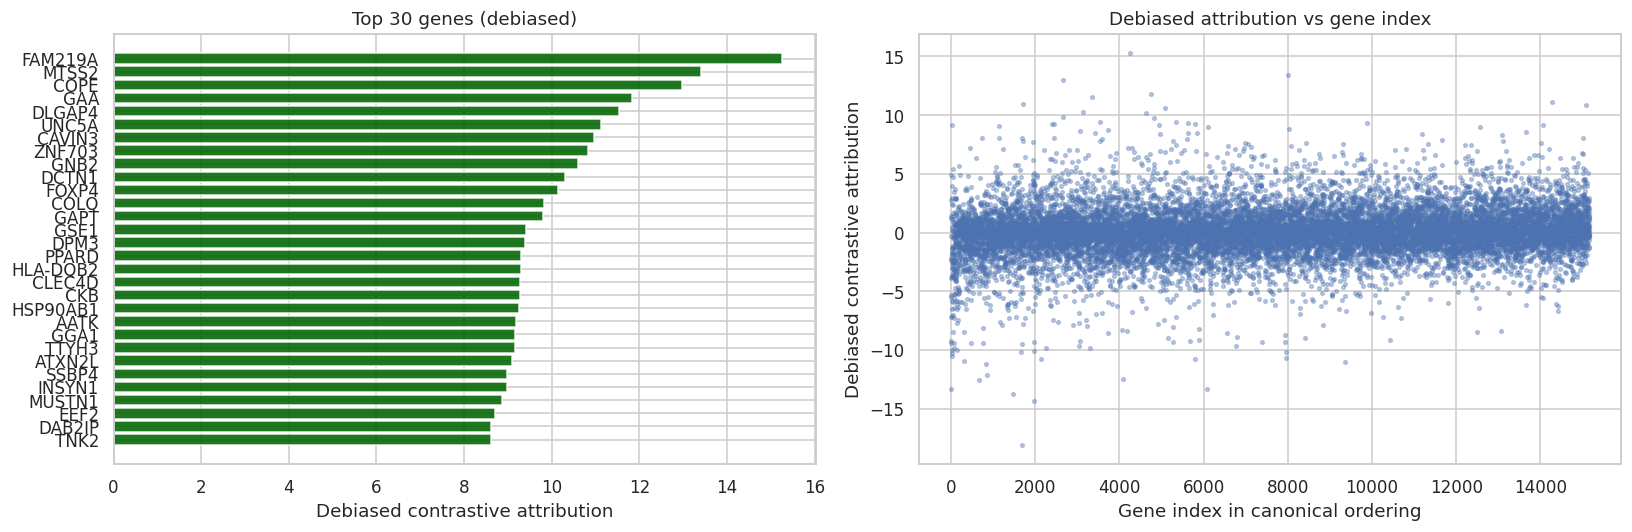

In [ ]:
# Debiased attribution ranking: remove index-dependent magnitude trend
# This addresses positional artifacts from canonical gene ordering.

# Raw contrast from previous cell: saliency_contrast = saliency_sp - saliency_ns
trend_window = 501  # odd window; smooth local index trend
local_scale = (
    pd.Series(np.abs(saliency_contrast))
    .rolling(window=trend_window, center=True, min_periods=50)
    .median()
    .bfill()
    .ffill()
    .to_numpy()
)

saliency_contrast_debiased = saliency_contrast / (local_scale + 1e-8)

TOP_DEB = 30
top_deb_idx = np.argsort(saliency_contrast_debiased)[::-1][:TOP_DEB]

deb_df = pd.DataFrame({
    "gene": [gene_order[i] for i in top_deb_idx],
    "debiased_score": saliency_contrast_debiased[top_deb_idx],
    "raw_contrast": saliency_contrast[top_deb_idx],
    "local_scale": local_scale[top_deb_idx],
    "rank": np.arange(1, TOP_DEB + 1),
})

print("Top 30 genes by DEBIASED contrastive attribution:")
display(deb_df)

# Letter-composition check after debiasing
deb_letters = pd.Series([g[0].upper() if g else "?" for g in deb_df["gene"]])
all_letters = pd.Series([g[0].upper() if g else "?" for g in gene_order])
letter_deb = pd.concat([
    deb_letters.value_counts(normalize=True).rename("top30_frac_debiased"),
    all_letters.value_counts(normalize=True).rename("background_frac"),
], axis=1).fillna(0.0)
letter_deb["enrichment"] = letter_deb["top30_frac_debiased"] / np.clip(letter_deb["background_frac"], 1e-12, None)
letter_deb = letter_deb.sort_values("enrichment", ascending=False)

print("\nFirst-letter enrichment after debiasing (top 30):")
display(letter_deb.head(10))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].barh(deb_df["gene"][::-1], deb_df["debiased_score"][::-1], color="darkgreen", alpha=0.88)
axes[0].set_xlabel("Debiased contrastive attribution")
axes[0].set_title("Top 30 genes (debiased)")

axes[1].scatter(np.arange(len(gene_order)), saliency_contrast_debiased, s=6, alpha=0.35)
axes[1].set_xlabel("Gene index in canonical ordering")
axes[1].set_ylabel("Debiased contrastive attribution")
axes[1].set_title("Debiased attribution vs gene index")

plt.tight_layout()
show_figure(fig)